In [1]:
# Get ELENA
!git clone https://github.com/michelelucente/ELENA.git
%cd ELENA

# Install Python deps for notebooks + examples
# (names follow ELENA’s README; CosmoTransitions is on PyPI)
%pip install -q numpy scipy matplotlib cosmoTransitions NatPy la-forge


Cloning into 'ELENA'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 624 (delta 168), reused 142 (delta 89), pack-reused 393 (from 1)
Receiving objects: 100% (624/624), 30.17 MiB | 15.96 MiB/s, done.
Resolving deltas: 100% (426/426), done.
/content/ELENA
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.7 MB/s eta 0:00:00


In [2]:
import sys
import os
from pathlib import Path
import numpy as np
import time

# Get the directory of the current script
script_dir = Path(os.getcwd()).resolve()

# Add the src directory to the Python path
sys.path.append(str(Path(script_dir / '../src').resolve()))

figure_dir = '../data/processed/plots/manual/'
if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)

In [3]:
def g_roll(lambda_):
    return ( ((16 * np.pi**2 * lambda_)/3) * (1 - lambda_ * (5 + 2*np.log(2) )/(8 * np.pi**2) ) )**(1/4)

In [4]:
# Add ELENA/src to the Python path for imports (as suggested by the repo)
import sys, os
sys.path.append(os.path.abspath('src'))

In [5]:
%%writefile custom_model.py
"""
Finite-temperature effective potential for the Abelian Higgs (dark photon) model,
consistent with arXiv:2511.02910 (Christiansen, Madge, Puchades-Ibáñez,
Ramirez-Quezada, Schwaller).

  V_eff(phi, T; mu) =
      V_tree(phi; mu)
    + V_CW(phi; mu)
    + V_T(phi, T; mu)
    + V_Daisy(phi, T; mu)

with

  V_tree(phi) = - m^2(mu) phi^2 / 2 + lambda(mu) phi^4 / 4

Field-dependent masses (Eq. A5):
  m_h^2(phi) = 3 lambda phi^2 - m^2
  m_g^2(phi) =   lambda phi^2 - m^2
  m_A^2(phi) = g^2 phi^2

Thermal masses (Eq. A9):
  Pi_{h,g} = lambda T^2 / 3 + g^2 T^2 / 4
  Pi_{A_L} = g^2 T^2 / 3
  Pi_{A_T} = 0   (transverse photon not Debye-resummed)

Coleman-Weinberg in MS-bar / Landau gauge (Eq. A4):
  V_CW = [ m_h^4 (ln(m_h^2/mu^2) - 3/2)
          + m_g^4 (ln(m_g^2/mu^2) - 3/2)
          + 3 m_A^4 (ln(m_A^2/mu^2) - 5/6) ] / (64 pi^2)

Arnold-Espinosa Daisy (Eq. 3):
  V_Daisy = - T/(12 pi) * sum_i n_i [ (m_i^2 + Pi_i)^{3/2} - (m_i^2)^{3/2} ]
  summed over H, G, A_L only (A_T contributes zero by construction).

One-loop RGEs (Eq. B1):
  beta_{g^2} = g^4 / (24 pi^2)
  beta_lambda = (10 lambda^2 - 6 lambda g^2 + 3 g^4) / (8 pi^2)
  beta_{m^2}  = m^2 (4 lambda - 3 g^2) / (8 pi^2)

Scale choice (Table I, paper default):
  mu(T) = pi T    for T > 0
  mu(0) = mu0     fallback

Conformal / scale-invariant benchmark (Sec. II, Table I):
  m^2(mu0) = 0,  lambda(mu0) = 0,  g(mu0) in [0.5, 1]
  => true minimum is generated radiatively (Coleman-Weinberg mechanism)
  => approxZeroTMin uses a numerical scan rather than the tree-level formula

Corrections vs. original file
-------------------------------
1. approxZeroTMin: replaced tree-level formula (fails when lambda <= 0 or m^2 <= 0)
   with a log-spaced numerical scan of V_CW + V_tree at T=0, which correctly
   locates the radiatively generated minimum in the conformal limit.

2. DVtot / alpha extraction: added a dedicated zero_T_vacuum_energy() helper that
   returns Delta V^0_eff = V(0,0) - V(v,0) at T=0, consistent with Eq. (6-7) of
   the paper.  The inherited DVtot(X,T) subtracts at the same T and should NOT be
   used to compute alpha directly.

3. boson_fun: added an explicit comment clarifying that the 'c' array is unused
   (use_ct_cw=False), so it cannot accidentally pollute V1/V1T.

4. FIX: dVdT and d2VdT2 were defined at module scope (wrong indentation level)
   instead of as methods of GenericCTModel. They are now correctly indented inside
   the class body.

5. Documentation strings updated throughout.
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

from cosmoTransitions import generic_potential, helper_functions


# -------------------------
# Small stability utilities
# -------------------------

def _as_float_array(x):
    return np.asanyarray(x, dtype=float)

def _as_float_scalar(x):
    return float(np.asanyarray(x, dtype=float))

def _clip_m2_nonneg(m2):
    return np.maximum(np.asanyarray(m2, dtype=float), 0.0)

def _finite_or_big(y, big=1e300):
    """Replace non-finite values with a large barrier number."""
    y = np.asanyarray(y)
    if np.isscalar(y) or y.shape == ():
        return y if np.isfinite(y) else big
    out = y.copy()
    mask = ~np.isfinite(out)
    if np.any(mask):
        out[mask] = big
    return out

def _adaptive_T_step(T, eps_abs=1e-6, eps_rel=1e-3, Tmin_step=1e-6):
    T = float(T)
    return max(float(eps_abs), float(eps_rel) * abs(T), float(Tmin_step))

def _safe_log_argument(x, floor=1e-300):
    x = np.asanyarray(x, dtype=float)
    return np.maximum(np.abs(x), floor)

def _safe_mass4_log_term(m2, mu2, const):
    """
    Compute  m^4 * [ ln(|m^2| / mu^2) - const ]
    in a numerically stable way (handles m^2 <= 0 via abs).
    """
    m2 = np.asanyarray(m2, dtype=float)
    mu2 = float(mu2)
    return (m2 ** 2) * (np.log(_safe_log_argument(m2) / mu2) - const)


# --------------------------------
# Generic CT-style engine
# --------------------------------

class GenericCTModel(generic_potential.generic_potential):
    """
    Generic CosmoTransitions-compatible wrapper.

    Callers supply:
      V0_fun(X, T)      : tree-level potential
      boson_fun(X, T)   : (M2, dof, c)  —  c is UNUSED when use_ct_cw=False
      fermion_fun(X)    : (M2, dof)
      Vct_fun(X, T)     : optional counterterm piece
      Vcw_fun(X, T)     : custom zero-T loop piece (used when use_ct_cw=False)
      use_ct_cw         : if True use CT's built-in V1; if False use Vcw_fun
      daisyType         : 0=none, 1=Parwani, 2=Arnold-Espinosa
    """

    def init(
        self,
        Ndim,
        V0_fun,
        boson_fun,
        fermion_fun=None,
        Vct_fun=None,
        Vcw_fun=None,
        use_ct_cw=False,
        xstep=1e-3,
        Tstep_abs=1e-4,
        Tstep_rel=1e-3,
        Tmin_step=1e-6,
        daisyType=2,
        deriv_order=2,
    ):
        self.Ndim = int(Ndim)
        if V0_fun is None or boson_fun is None:
            raise ValueError("GenericCTModel requires at least V0_fun and boson_fun.")

        self._V0_fun      = V0_fun
        self._boson_fun   = boson_fun
        self._fermion_fun = fermion_fun if fermion_fun is not None else (lambda X: (0.0, 0.0))
        self._Vct_fun     = Vct_fun     if Vct_fun     is not None else (lambda X, T: 0.0)
        self._Vcw_fun     = Vcw_fun     if Vcw_fun     is not None else (lambda X, T: 0.0)

        self.use_ct_cw  = bool(use_ct_cw)
        self.x_eps      = float(xstep)
        self.T_eps_abs  = float(Tstep_abs)
        self.T_eps_rel  = float(Tstep_rel)
        self.Tmin_step  = float(Tmin_step)
        self.daisyResum = int(daisyType)
        self.deriv_order = int(deriv_order)

    # --- CT interface ----------------------------------------------------------

    def V0(self, X):
        return self._V0_fun(_as_float_array(X), 0.0)

    def Vct(self, X):
        return self._Vct_fun(_as_float_array(X), 0.0)

    def boson_massSq(self, X, T):
        return self._boson_fun(_as_float_array(X), _as_float_scalar(T))

    def fermion_massSq(self, X):
        return self._fermion_fun(_as_float_array(X))

    # --- Full effective potential -----------------------------------------------

    def Vtot(self, X, T, include_radiation=True):
        X = _as_float_array(X)
        T = _as_float_array(T)

        fermions = self.fermion_massSq(X)
        bosons0  = self.boson_massSq(X, 0.0 * T)   # zero-T field-dependent masses

        # Tree-level
        y = self._V0_fun(X, T)

        # Zero-temperature loop piece
        if self.use_ct_cw:
            y = y + self.V1(bosons0, fermions) + self._Vct_fun(X, T)
        else:
            y = y + self._Vcw_fun(X, T) + self._Vct_fun(X, T)

        # Thermal + Daisy
        if self.daisyResum == 0:
            # No resummation: pass bare zero-T masses to V1T
            y = y + self.V1T(bosons0, fermions, T, include_radiation)

        elif self.daisyResum == 1:
            # Parwani: replace bare masses with thermally corrected masses everywhere
            bosonsT = self.boson_massSq(X, T)
            y = y + self.V1T(bosonsT, fermions, T, include_radiation)

        elif self.daisyResum == 2:
            # Arnold-Espinosa (paper Eq. 3):
            #   V1T with bare masses  +  ring correction from (m^2+Pi)^{3/2} - (m^2)^{3/2}
            bosonsT = self.boson_massSq(X, T)
            m20, nb, _ = bosons0
            m2T, _,  _ = bosonsT

            m20c = _clip_m2_nonneg(m20)
            m2Tc = _clip_m2_nonneg(m2T)

            # Ring term:  -T/(12 pi) * sum_i n_i [ (m2T_i)^{3/2} - (m20_i)^{3/2} ]
            # For A_T: m2T == m20 (no thermal shift), so its contribution is exactly 0.
            Vring = -(T / (12.0 * np.pi)) * np.sum(
                nb * (np.power(m2Tc, 1.5) - np.power(m20c, 1.5)),
                axis=-1
            )
            y = y + self.V1T(bosons0, fermions, T, include_radiation) + Vring

        else:
            raise ValueError("daisyType must be 0, 1, or 2.")

        return _finite_or_big(y)

    def DVtot(self, X, T):
        """
        Potential difference relative to origin AT THE SAME T.
        Useful for plotting; do NOT use for alpha (see zero_T_vacuum_energy).
        """
        return (self.Vtot(X, T, include_radiation=False)
                - self.Vtot(X * 0.0, T, include_radiation=False))

    def gradV(self, X, T):
        try:
            f = self._gradV
        except AttributeError:
            self._gradV = helper_functions.gradientFunction(
                self.Vtot, self.x_eps, self.Ndim, self.deriv_order
            )
            f = self._gradV
        T = np.asanyarray(T)[..., np.newaxis, np.newaxis]
        return f(X, T, False)

    # --- Temperature derivatives -----------------------------------------------

    def dVdT(self, X, T, include_radiation=True,
             include_SM=False, units="GeV", g_star_SM=106.75):
        X = _as_float_array(X)
        T = float(T)
        h = _adaptive_T_step(T, self.T_eps_abs, self.T_eps_rel, self.Tmin_step)

        if T <= h:
            V0 = self.Vtot(X, 0.0, include_radiation=include_radiation)
            V1 = self.Vtot(X,   h, include_radiation=include_radiation)
            result = (V1 - V0) / h
        else:
            Vm = self.Vtot(X, T - h, include_radiation=include_radiation)
            Vp = self.Vtot(X, T + h, include_radiation=include_radiation)
            result = (Vp - Vm) / (2.0 * h)

        # Add SM radiation contribution if requested
        if include_SM:
            result += -(2.0 * np.pi**2 / 45.0) * g_star_SM * T**3

        return result

    def d2VdT2(self, X, T, include_radiation=True,
               include_SM=False, units="GeV", g_star_SM=106.75):
        X = _as_float_array(X)
        T = float(T)
        h = _adaptive_T_step(T, self.T_eps_abs, self.T_eps_rel, self.Tmin_step)

        if T <= 2.0 * h:
            V0  = self.Vtot(X,       0.0, include_radiation=include_radiation)
            Vh  = self.Vtot(X,         h, include_radiation=include_radiation)
            V2h = self.Vtot(X, 2.0 * h,  include_radiation=include_radiation)
            result = (V2h - 2.0 * Vh + V0) / (h * h)
        else:
            Vm = self.Vtot(X, T - h, include_radiation=include_radiation)
            Vc = self.Vtot(X,     T, include_radiation=include_radiation)
            Vp = self.Vtot(X, T + h, include_radiation=include_radiation)
            result = (Vp - 2.0 * Vc + Vm) / (h * h)

        # Add SM radiation contribution if requested
        if include_SM:
            result += -(2.0 * np.pi**2 / 15.0) * g_star_SM * T**2

        return result


# ---------------------------------------------------------
# Paper-consistent Abelian-Higgs 4D HT + Daisy model
# ---------------------------------------------------------

class AbelianHiggsMSbarPaper(GenericCTModel):
    """
    One-loop 4D high-temperature potential with Arnold-Espinosa Daisy resummation
    for the dark Abelian Higgs model, consistent with arXiv:2511.02910.

    Default benchmark (Table I):
        m^2(mu0) = 0,  lambda(mu0) = 0,  g(mu0) in [0.5, 1],  mu0 = 1 GeV
        mu(T) = pi T  (minimises large logs in the thermal regime)

    The true minimum in the conformal limit is generated radiatively by the
    Coleman-Weinberg mechanism and is found by a numerical scan in
    approxZeroTMin().  The zero-temperature vacuum energy difference needed
    for alpha (Eq. 7) is provided by zero_T_vacuum_energy().
    """

    def init(
        self,
        g2_0=0.64,          # g(mu0)^2  [paper benchmark: g=0.6 => g2=0.36]
        lambda_0=0.0,        # lambda(mu0)  [conformal limit: 0]
        m2_0=0.0,            # m^2(mu0)    [conformal limit: 0]
        mu0=1.0,             # reference scale (GeV)
        use_running=True,
        use_paper_mu=True,   # mu(T) = pi T for T>0, else mu0
        xstep=5e-5,
        Tstep_abs=1e-4,
        Tstep_rel=1e-3,
        Tmin_step=1e-6,
        deriv_order=2,
        daisyType=2,         # Arnold-Espinosa by default
        phi_scan_points=500, # points for the zero-T minimum scan
        phi_scan_decades=6,  # log-decades above mu0 to scan
    ):
        self.g2_0      = float(g2_0)
        self.lambda_0  = float(lambda_0)
        self.m2_0      = float(m2_0)
        self.mu0       = float(mu0)

        self.use_running  = bool(use_running)
        self.use_paper_mu = bool(use_paper_mu)

        self._phi_scan_points  = int(phi_scan_points)
        self._phi_scan_decades = float(phi_scan_decades)

        # RGE cache
        self._rge_cache = {}

        # ---------------------------------------------------------------
        # Scale choice: mu(T) = pi T (paper Table I, 4D HT column)
        # ---------------------------------------------------------------
        def mu_eff(T):
            T = float(np.asanyarray(T, dtype=float))
            if self.use_paper_mu and T > 0.0:
                return max(np.pi * T, 1e-12)
            return max(self.mu0, 1e-12)

        self.mu_eff = mu_eff

        # ---------------------------------------------------------------
        # One-loop RGEs (paper Eq. B1)
        # ---------------------------------------------------------------
        def rge_rhs(t, y):
            # t = ln(mu / mu0)
            g2, lam, m2 = y
            beta_g2  = (g2 ** 2) / (24.0 * np.pi ** 2)
            beta_lam = (10.0 * lam**2 - 6.0 * lam * g2 + 3.0 * g2**2) / (8.0 * np.pi**2)
            beta_m2  = m2 * (4.0 * lam - 3.0 * g2) / (8.0 * np.pi**2)
            return [beta_g2, beta_lam, beta_m2]

        self._rge_rhs = rge_rhs

        def run_params(mu):
            """Return (g^2, lambda, m^2) at scale mu via RK45 integration."""
            mu = max(float(mu), 1e-12)

            if not self.use_running:
                return self.g2_0, self.lambda_0, self.m2_0

            key = round(mu, 12)
            if key in self._rge_cache:
                return self._rge_cache[key]

            if abs(mu - self.mu0) / max(self.mu0, 1e-12) < 1e-14:
                out = (self.g2_0, self.lambda_0, self.m2_0)
                self._rge_cache[key] = out
                return out

            t1  = np.log(mu / self.mu0)
            sol = solve_ivp(
                self._rge_rhs,
                (0.0, t1),
                [self.g2_0, self.lambda_0, self.m2_0],
                method="RK45",
                rtol=1e-8,
                atol=1e-10,
                dense_output=False,
                max_step=max(abs(t1) / 100.0, 1e-3),
            )
            if not sol.success:
                raise RuntimeError(f"RGE evolution failed: {sol.message}")

            g2_mu, lam_mu, m2_mu = [float(v) for v in sol.y[:, -1]]
            out = (g2_mu, lam_mu, m2_mu)
            self._rge_cache[key] = out
            return out

        self.run_params = run_params

        # ---------------------------------------------------------------
        # Field-dependent masses at (phi, T) — Eq. A5
        # ---------------------------------------------------------------
        def masses_zeroT(phi, T):
            mu              = self.mu_eff(T)
            g2, lam, m2    = self.run_params(mu)
            mH2 = 3.0 * lam * phi**2 - m2
            mG2 = 1.0 * lam * phi**2 - m2
            mA2 = g2 * phi**2
            return mH2, mG2, mA2, g2, lam, m2, mu

        self.masses_zeroT = masses_zeroT

        # ---------------------------------------------------------------
        # Tree-level potential — Eq. A3
        # ---------------------------------------------------------------
        def V0_fun(X, T):
            X   = _as_float_array(X)
            phi = X[..., 0]
            _, _, _, _, lam, m2, _ = self.masses_zeroT(phi, T)
            return -0.5 * m2 * phi**2 + 0.25 * lam * phi**4

        # ---------------------------------------------------------------
        # MS-bar Coleman-Weinberg — Eq. A4
        # ---------------------------------------------------------------
        def Vcw_msbar(X, T):
            """
            V_CW = [ m_h^4 (ln(m_h^2/mu^2)-3/2)
                   + m_g^4 (ln(m_g^2/mu^2)-3/2)
                   + 3*m_A^4 (ln(m_A^2/mu^2)-5/6) ] / (64 pi^2)

            Logarithms use |m^2| for numerical stability when m^2 < 0.
            """
            X   = _as_float_array(X)
            phi = X[..., 0]
            mH2, mG2, mA2, _, _, _, mu = self.masses_zeroT(phi, T)
            mu2 = mu**2

            termH = _safe_mass4_log_term(mH2, mu2, 1.5)        # scalar (Higgs)
            termG = _safe_mass4_log_term(mG2, mu2, 1.5)        # Goldstone
            termA = 3.0 * _safe_mass4_log_term(mA2, mu2, 5.0/6.0)  # 3 gauge dof

            return (termH + termG + termA) / (64.0 * np.pi**2)

        # ---------------------------------------------------------------
        # Bosonic spectrum for V1T and the Daisy ring term
        #
        # Species:  [H,   G,   A_T, A_L]
        # dof:      [1,   1,   2,   1  ]
        #
        # Thermal masses (Eq. A9):
        #   Pi_{H,G} = lambda T^2/3 + g^2 T^2/4
        #   Pi_{A_L} = g^2 T^2/3
        #   Pi_{A_T} = 0   (transverse mode: not Debye-resummed)
        #
        # NOTE: the 'c' array below is ONLY used by CT's internal V1 (CW),
        # which is disabled here (use_ct_cw=False).  It has no effect on
        # V_CW (handled by Vcw_msbar above) or on V1T / the Daisy ring.
        # ---------------------------------------------------------------
        def boson_fun(X, T):
            X   = _as_float_array(X)
            phi = X[..., 0]
            T   = float(np.asanyarray(T, dtype=float))

            mH2, mG2, mA2, g2, lam, _, _ = self.masses_zeroT(phi, T)

            if T > 0.0:
                PiS = (lam / 3.0 + g2 / 4.0) * T**2   # Higgs / Goldstone
                PiL = (g2 / 3.0) * T**2                 # longitudinal photon

                mH2_eff  = mH2 + PiS
                mG2_eff  = mG2 + PiS
                mAT2_eff = mA2          # A_T: no Debye mass
                mAL2_eff = mA2 + PiL   # A_L: gets Debye mass
            else:
                mH2_eff  = mH2
                mG2_eff  = mG2
                mAT2_eff = mA2
                mAL2_eff = mA2

            M2  = np.stack([mH2_eff, mG2_eff, mAT2_eff, mAL2_eff], axis=-1)
            dof = np.array([1.0, 1.0, 2.0, 1.0])
            # c values match Landau-gauge CW constants — UNUSED with use_ct_cw=False
            c   = np.array([1.5, 1.5, 5.0/6.0, 5.0/6.0])
            return M2, dof, c

        def fermion_fun(X):
            return 0.0, 0.0

        # ---------------------------------------------------------------
        # Initialise parent
        # ---------------------------------------------------------------
        super().init(
            Ndim=1,
            V0_fun=V0_fun,
            boson_fun=boson_fun,
            fermion_fun=fermion_fun,
            Vct_fun=None,
            Vcw_fun=Vcw_msbar,
            use_ct_cw=False,
            xstep=xstep,
            Tstep_abs=Tstep_abs,
            Tstep_rel=Tstep_rel,
            Tmin_step=Tmin_step,
            daisyType=daisyType,
            deriv_order=deriv_order,
        )

    # -----------------------------------------------------------------------
    # FIX 1: Zero-temperature minimum via numerical scan
    # -----------------------------------------------------------------------
    def approxZeroTMin(self):
        """
        Locate the zero-temperature minimum by scanning V_tree + V_CW over a
        log-spaced grid and then refining with a scalar minimiser.

        This replaces the tree-level formula phi^2 = m^2/lambda, which fails
        in the conformal limit (m^2=0, lambda~0) where the minimum is generated
        radiatively by the Coleman-Weinberg mechanism.

        The scan covers phi in [mu0 * 10^{-phi_scan_decades/2},
                                 mu0 * 10^{+phi_scan_decades/2}]
        on a log scale plus phi=0.  If no non-trivial minimum is found,
        returns [0.0].
        """
        # zero-T potential as a function of scalar phi
        def V0T(phi):
            X = np.array([float(phi)])
            return float(self.Vtot(X, 0.0, include_radiation=False))

        # Build log-spaced scan grid
        phi_lo  = self.mu0 * 10.0 ** (-self._phi_scan_decades / 2.0)
        phi_hi  = self.mu0 * 10.0 ** ( self._phi_scan_decades / 2.0)
        phi_grid = np.logspace(
            np.log10(phi_lo), np.log10(phi_hi), self._phi_scan_points
        )

        V_grid   = np.array([V0T(p) for p in phi_grid])
        V_origin = V0T(1e-15 * self.mu0)   # approximate V(0)

        # Find the grid index of the global minimum
        idx_min  = int(np.argmin(V_grid))

        if V_grid[idx_min] >= V_origin:
            # No non-trivial minimum found on the grid
            return [np.array([0.0], dtype=float)]

        # Refine with a bounded scalar minimiser around the grid minimum
        lo_refine = phi_grid[max(idx_min - 1, 0)]
        hi_refine = phi_grid[min(idx_min + 1, len(phi_grid) - 1)]

        res = minimize_scalar(V0T, bounds=(lo_refine, hi_refine), method="bounded",
                              options={"xatol": 1e-10 * phi_grid[idx_min]})

        vev = float(res.x) if res.success else phi_grid[idx_min]
        return [np.array([vev], dtype=float)]

    # -----------------------------------------------------------------------
    # FIX 2: Zero-temperature vacuum energy for alpha (paper Eq. 6-7)
    # -----------------------------------------------------------------------
    def zero_T_vacuum_energy(self):
        """
        Compute Delta V^0_eff = V(phi=0, T=0) - V(phi=v, T=0)
                               = |V(phi=v, T=0)|
        at zero temperature, as required for the strength parameter alpha
        (Eq. 7 of arXiv:2511.02910) and the Hubble rate (Eq. 6).

        Returns
        -------
        DeltaV : float
            Positive definite vacuum energy difference at T=0.
        vev : float
            The field value of the zero-T true minimum.
        """
        mins   = self.approxZeroTMin()
        vev    = float(mins[0][0])

        if vev < 1e-30 * self.mu0:
            # No non-trivial minimum; transition has not occurred
            return 0.0, 0.0

        X_vev = np.array([vev])
        X_fv  = np.array([0.0])

        V_vev = float(self.Vtot(X_vev, 0.0, include_radiation=False))
        V_fv  = float(self.Vtot(X_fv,  0.0, include_radiation=False))

        DeltaV = V_fv - V_vev      # >0 if vev is the true minimum
        return max(DeltaV, 0.0), vev

    # -----------------------------------------------------------------------
    # Convenience: strength parameter alpha at nucleation temperature Tn
    # -----------------------------------------------------------------------
    def alpha_parameter(self, Tn, g_star=100.0):
        """
        alpha = Delta V^0_eff / rho_R(Tn)   (paper Eq. 7)

        Parameters
        ----------
        Tn     : float   nucleation temperature
        g_star : float   relativistic d.o.f. (default 100)

        Returns
        -------
        alpha : float
        """
        DeltaV, _ = self.zero_T_vacuum_energy()
        rho_R      = (np.pi**2 / 30.0) * g_star * float(Tn)**4
        return DeltaV / rho_R if rho_R > 0 else np.inf


# Compatibility alias
DarkPhotonMSbarRG = AbelianHiggsMSbarPaper

Writing custom_model.py


In [6]:
import numpy as np
from utils import convert_units
from custom_model import AbelianHiggsMSbarPaper

# Paper benchmark:
# input at mu0 = 1 GeV
# g(mu0) = 0.6
# lambda(mu0) = 0
# m2(mu0) = 0
# mu(T) = pi*T

g = 0.6
g2_0 = g**2
lambda_0 = 0.0
m2_0 = 0.0
mu0 = 1.0      # GeV
vev = 1.0      # use GeV units for the paper normalization
units = "GeV"
description = "4D: g(mu0)=0.6"

dp = AbelianHiggsMSbarPaper(
    g2_0=g2_0,
    lambda_0=lambda_0,
    m2_0=m2_0,
    mu0=mu0,
    use_running=True,
    use_paper_mu=True,
    xstep=vev * 1e-3,
    Tstep_abs=vev * 1e-4,
    Tstep_rel=1e-3,
    daisyType=2,      # Arnold-Espinosa
)

V = dp.DVtot
dV = dp.gradV

print(f"g(mu0) = {g}")
print(f"g2(mu0) = {g2_0}")
print(f"lambda(mu0) = {lambda_0}")
print(f"m2(mu0) = {m2_0}")
print(f"mu0 = {mu0} {units}")
print(f"scale choice: mu(T) = pi*T")
print(f"description = {description}")

/usr/local/lib/python3.12/dist-packages/cosmoTransitions/finiteT.py:88: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integrate.quad(f1, 0, abs(theta)**.5)[0]


g(mu0) = 0.6
g2(mu0) = 0.36
lambda(mu0) = 0.0
m2(mu0) = 0.0
mu0 = 1.0 GeV
scale choice: mu(T) = pi*T
description = 4D: g(mu0)=0.6


In [7]:
import numpy as np
from temperatures import find_T_min, find_T_max, refine_Tmin

units = "GeV"

scan_scale = 1.0   # GeV


def V(phi, T):
    phi_arr = np.atleast_1d(phi).astype(float).reshape(-1, 1)
    out = dp.DVtot(phi_arr, T)
    return np.asarray(out, dtype=float)

def dV(phi, T):
    phi_arr = np.atleast_1d(phi).astype(float).reshape(-1, 1)
    out = dp.gradV(phi_arr, T)[..., 0]
    return np.asarray(out, dtype=float)

T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(
    V,
    dV,
    precision=1e-2,
    Phimax=2.0 * scan_scale,
    step_phi=1e-2 * scan_scale,
    tmax=2.5 * scan_scale,
)

T_min, vevs_min, false_min_tmin = find_T_min(
    V,
    dV,
    tmax=T_max,
    precision=1e-2,
    Phimax=2.0 * scan_scale,
    step_phi=1e-2 * scan_scale,
    max_min_vals=max_min_vals,
)

if T_max is not None and T_min is not None:
    maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
elif T_max is not None:
    maxvev = np.max(vevs_max)
elif T_min is not None:
    maxvev = np.max(vevs_min)
else:
    maxvev = None

T_min = refine_Tmin(T_min, V, dV, maxvev, log_10_precision=6) if T_min is not None else None

if T_max is not None:
    print(f"T_max = {T_max:.6e} {units}")
else:
    print("T_max = None")

if T_min is not None:
    print(f"T_min = {T_min:.6e} {units}")
else:
    print("T_min = None")

print("maxvev =", maxvev)

T_max = 3.755000e-01 GeV
T_min = 2.138922e-03 GeV
maxvev = 2.3318096941652984


In [8]:
T_max, vevs_max, max_min_vals, false_min_tmax

(np.float64(0.37550000000000777),
 array([1.87737959, 1.8774014 , 1.87668692]),
 [0.9504355671527963, 1.876686919169872],
 [0, 0])

In [9]:
T_min, vevs_min, false_min_tmin

(np.float64(0.0021389220519981633), array([2.33180969]), [0, 0])

In [10]:
maxvev

np.float64(2.3318096941652984)

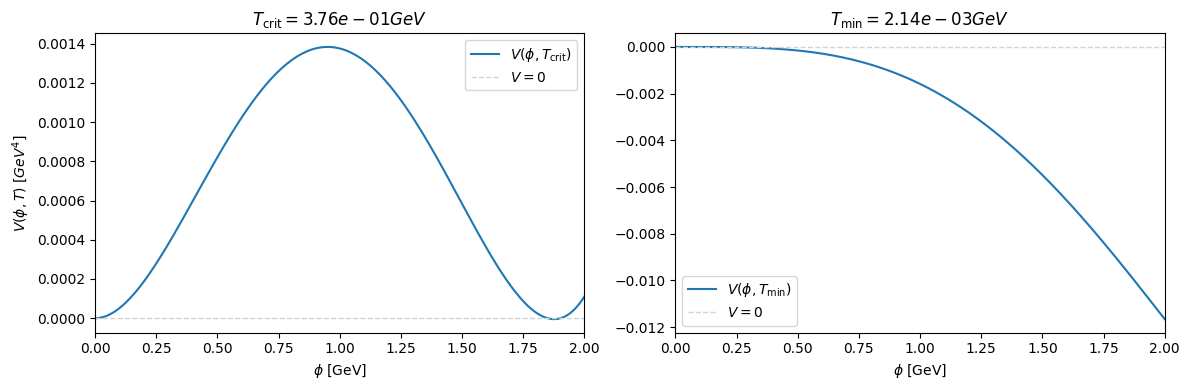

In [11]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False

# Define a plotting range (no vev anymore)
phi = np.linspace(0.0, 2.0, 200)  # adjust if needed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------
# Critical temperature plot
# -------------------------
if T_max is not None:
    v_max = V(phi, T_max)
    axes[0].plot(phi, v_max, label=r'$V(\phi, T_{\mathrm{crit}})$')
    axes[0].set_title(f'$T_{{\\mathrm{{crit}}}} = {T_max:.2e} {units}$')
    axes[0].set_xlim(phi[0], phi[-1])
    axes[0].set_ylabel(f"$V(\\phi, T)$ $[{units}^4]$")

# -------------------------
# Barrier disappearance plot
# -------------------------
if T_min is not None:
    v_min = V(phi, T_min)
    axes[1].plot(phi, v_min, label=r'$V(\phi, T_{\mathrm{min}})$')
    axes[1].set_title(f'$T_{{\\mathrm{{min}}}} = {T_min:.2e} {units}$')
    axes[1].set_xlim(phi[0], phi[-1])

# -------------------------
# Common formatting
# -------------------------
for ax in axes:
    ax.set_xlabel(f"$\\phi$ [{units}]")
    ax.axhline(0.0, color='lightgrey', linestyle='--', linewidth=1, label="$V=0$")
    ax.legend()

plt.tight_layout()
plt.show()

In [12]:
from espinosa import Vt_vec
import numpy as np

true_vev = {}
S3overT = {}
V_min_value = {}
phi0_min = {}
V_exit = {}
false_vev = {}

def action_over_T(T, c_step_phi=1e-3, precision=1e-3):
    T = float(T)

    # Fallback if maxvev was not determined cleanly
    vev0_guess = float(maxvev) if maxvev is not None and np.isfinite(maxvev) and maxvev > 0 else 1.0

    instance = Vt_vec(
        T,
        V,
        dV,
        step_phi=c_step_phi,
        precision=precision,
        vev0=vev0_guess,
        ratio_vev_step0=50,
    )

    if instance.barrier:
        true_vev[T] = float(instance.true_min)
        false_vev[T] = float(instance.phi_original_false_vev)
        S3overT[T] = float(instance.action_over_T)
        V_min_value[T] = float(instance.min_V)
        phi0_min[T] = float(instance.phi0_min)
        V_exit[T] = float(instance.V_exit)
        return float(instance.action_over_T)
    else:
        return None

In [13]:
import time
import numpy as np

n_points = 100

if T_min is None or T_max is None:
    raise RuntimeError("T_min or T_max is None. Run the temperature finder first and make sure a barrier exists.")

temperatures_scan = np.linspace(float(T_min), float(T_max), n_points)
action_vec = np.vectorize(action_over_T, otypes=[object])

start_time = time.time()
_ = action_vec(temperatures_scan)
end_time = time.time()

print(f"Elapsed time: {end_time - start_time:.2f} seconds")

# Keep only temperatures where the action was successfully computed
temperatures = np.array(
    [float(T) for T in temperatures_scan if float(T) in S3overT],
    dtype=float
)

if len(temperatures) == 0:
    raise RuntimeError("No valid S3/T points were computed. Try increasing the scan range or adjusting step_phi / vev0.")

/tmp/ipykernel_3463/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


Elapsed time: 4.35 seconds


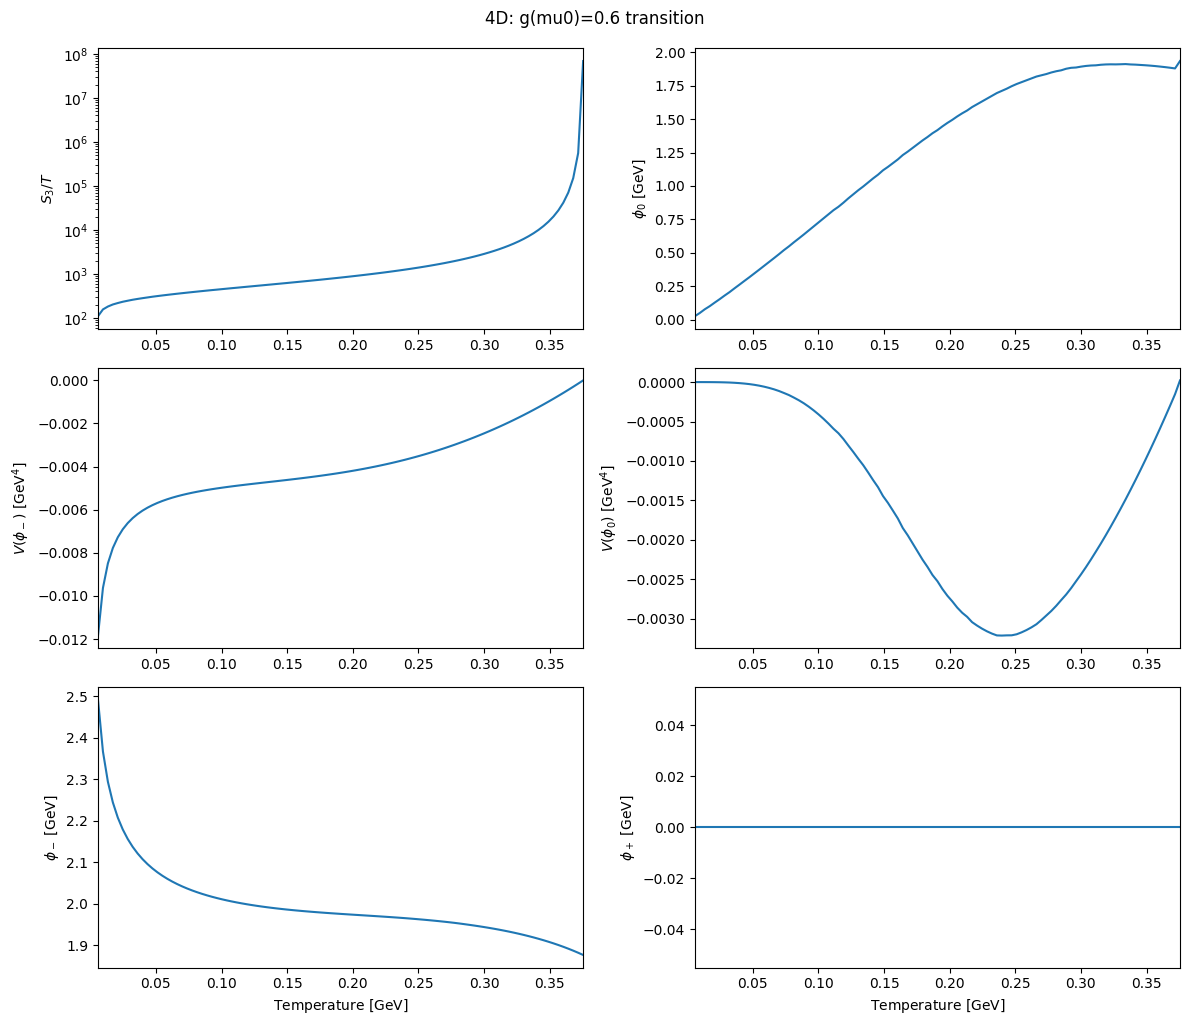

Minimum of the action at T = 5.91e-03 GeV


In [14]:
import matplotlib.pyplot as plt
import os

if len(temperatures) == 0:
    raise RuntimeError("No temperatures available for plotting.")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

S3_vals      = np.array([S3overT[T] for T in temperatures], dtype=float)
phi0_vals    = np.array([phi0_min[T] for T in temperatures], dtype=float)
Vmin_vals    = np.array([V_min_value[T] for T in temperatures], dtype=float)
Vexit_vals   = np.array([V_exit[T] for T in temperatures], dtype=float)
true_vals    = np.array([true_vev[T] for T in temperatures], dtype=float)
false_vals   = np.array([false_vev[T] for T in temperatures], dtype=float)

axes[0, 0].plot(temperatures, S3_vals)
axes[0, 0].set_ylabel(r'$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(temperatures, phi0_vals)
axes[0, 1].set_ylabel(f"$\\phi_0\\ \\mathrm{{[{units}]}}$")

axes[1, 0].plot(temperatures, Vmin_vals)
axes[1, 0].set_ylabel(f"$V(\\phi_-)\\ \\mathrm{{[{units}^4]}}$")

axes[1, 1].plot(temperatures, Vexit_vals)
axes[1, 1].set_ylabel(f"$V(\\phi_0)\\ \\mathrm{{[{units}^4]}}$")

axes[2, 0].plot(temperatures, true_vals)
axes[2, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 0].set_ylabel(f"$\\phi_-\\ \\mathrm{{[{units}]}}$")

axes[2, 1].plot(temperatures, false_vals)
axes[2, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 1].set_ylabel(f"$\\phi_+\\ \\mathrm{{[{units}]}}$")

for ax in axes.flatten():
    ax.set_xlim(np.min(temperatures), np.max(temperatures))

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.02)

# Save only if figure_dir exists
if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"action_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

T_at_min_action = temperatures[np.argmin(S3_vals)]
print(f"Minimum of the action at T = {T_at_min_action:.2e} {units}")

In [15]:
from utils import interpolation_narrow
from temperatures import compute_logP_f, N_bubblesH, R_sepH
import numpy as np

is_physical = True

def is_increasing(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) < 2:
        return True
    return np.all(arr[:-1] <= arr[1:])

counter = 0
while counter <= 1:
    # Refined second pass around the milestone region
    if counter == 1:
        if np.isfinite(T_completion) and np.isfinite(T_nuc):
            T_lo = np.nanmax([T_min, 0.95 * T_completion])
            T_hi = np.nanmin([T_max, 1.05 * T_nuc])

            if np.isfinite(T_lo) and np.isfinite(T_hi) and T_hi > T_lo:
                temperatures_refined = np.linspace(T_lo, T_hi, n_points, endpoint=True)
                _ = action_vec(temperatures_refined)

    logP_f, Temps, ratio_V, Gamma, H = compute_logP_f(
        dp,
        V_min_value,
        S3overT,
        v_w=1,
        units=units,
        cum_method='None'
    )

    RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
    nH = N_bubblesH(Temps, Gamma, logP_f, H, ratio_V)

    Temps   = np.asarray(Temps, dtype=float)
    logP_f  = np.asarray(logP_f, dtype=float)
    ratio_V = np.asarray(ratio_V, dtype=float)
    Gamma   = np.asarray(Gamma, dtype=float)
    H       = np.asarray(H, dtype=float)
    nH      = np.asarray(nH, dtype=float)

    # Nucleation: N_bubbles / Hubble volume = 1  -> log(nH)=0
    mask_nH = np.isfinite(nH) & (nH > 0) & np.isfinite(Temps)
    if np.any(mask_nH):
        T_nuc = interpolation_narrow(np.log(nH[mask_nH]), Temps[mask_nH], 0.0)
    else:
        T_nuc = np.nan

    # Percolation/completion from Pf
    mask_Pf = np.isfinite(logP_f) & np.isfinite(Temps)
    if np.any(mask_Pf):
        T_perc = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.71))
        T_completion = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.01))
    else:
        T_perc = np.nan
        T_completion = np.nan

    # Completion sanity check
    if np.isfinite(T_completion):
        idx_compl = int(np.argmin(np.abs(Temps - T_completion)))
        idx_lo = max(idx_compl - 1, 0)
        idx_hi = min(idx_compl + 2, len(Temps))
        test_completion = logP_f[idx_lo:idx_hi]
        test_completion = test_completion[np.isfinite(test_completion)]

        print(counter, T_completion, test_completion)
        print(is_increasing(test_completion))

        if not is_increasing(test_completion):
            T_completion = np.nan
    else:
        print(counter, T_completion, np.array([]))
        print(True)

    # Physical-volume check on second pass
    if counter == 1:
        d_dT_logP_f = np.gradient(logP_f, Temps)

        if np.isfinite(T_perc):
            log_at_T_perc = interpolation_narrow(Temps, d_dT_logP_f, T_perc)
            ratio_V_at_T_perc = interpolation_narrow(Temps, ratio_V, T_perc)

            if np.isfinite(log_at_T_perc) and np.isfinite(ratio_V_at_T_perc):
                if ratio_V_at_T_perc > log_at_T_perc:
                    is_physical = False
                    print("\n*** The physical volume at percolation is not decreasing. The production of GW is questionable. ***")

        if np.isfinite(T_completion):
            log_at_T_completion = interpolation_narrow(Temps, d_dT_logP_f, T_completion)
            ratio_V_at_T_completion = interpolation_narrow(Temps, ratio_V, T_completion)
            # Stored only if you want later inspection

    counter += 1

# Make sure milestone temperatures are in the action dictionaries
milestones = [T_max, T_nuc, T_perc, T_completion, T_min]
milestones = [float(m) for m in milestones if m is not None and np.isfinite(m)]
if len(milestones) > 0:
    _ = action_vec(np.array(milestones, dtype=float))

# For plotting windows
milestone_window = [T_completion, T_perc, T_nuc]
milestone_window = [m for m in milestone_window if np.isfinite(m)]

if len(milestone_window) > 0:
    t_mil_min = np.nanmin(milestone_window)
    t_mil_max = np.nanmax(milestone_window)

    idx_min = max(int(np.argmin(np.abs(Temps - t_mil_min))), 0)
    idx_max = min(int(np.argmin(np.abs(Temps - t_mil_max))), len(Temps) - 1)

    idx_min = idx_min if Temps[idx_min] <= t_mil_min else max(idx_min - 1, 0)
    idx_max = idx_max if Temps[idx_max] >= t_mil_max else min(idx_max + 1, len(Temps) - 1)

    mask = (Temps >= Temps[idx_min]) & (Temps <= Temps[idx_max])
else:
    mask = Temps >= 0

print()
print(f"T_nuc = {T_nuc:.6e} {units}" if np.isfinite(T_nuc) else "T_nuc = nan")
print(f"T_perc = {T_perc:.6e} {units}" if np.isfinite(T_perc) else "T_perc = nan")
print(f"T_completion = {T_completion:.6e} {units}" if np.isfinite(T_completion) else "T_completion = nan")
print()

/content/ELENA/src/temperatures.py:433: RuntimeWarning: divide by zero encountered in power
  return n**(-1/3) * H, n**(-1/3)
/tmp/ipykernel_3463/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


0 0.009680161431159046 [-1.23291538e+04 -2.20357572e-07 -4.37787064e-16]
True
1 0.009416633388523868 [-5.97908838 -5.00610522 -4.17336536]
True

T_nuc = 1.097520e-02 GeV
T_perc = 9.750472e-03 GeV
T_completion = 9.416633e-03 GeV



In [16]:
T_min

np.float64(0.0021389220519981633)

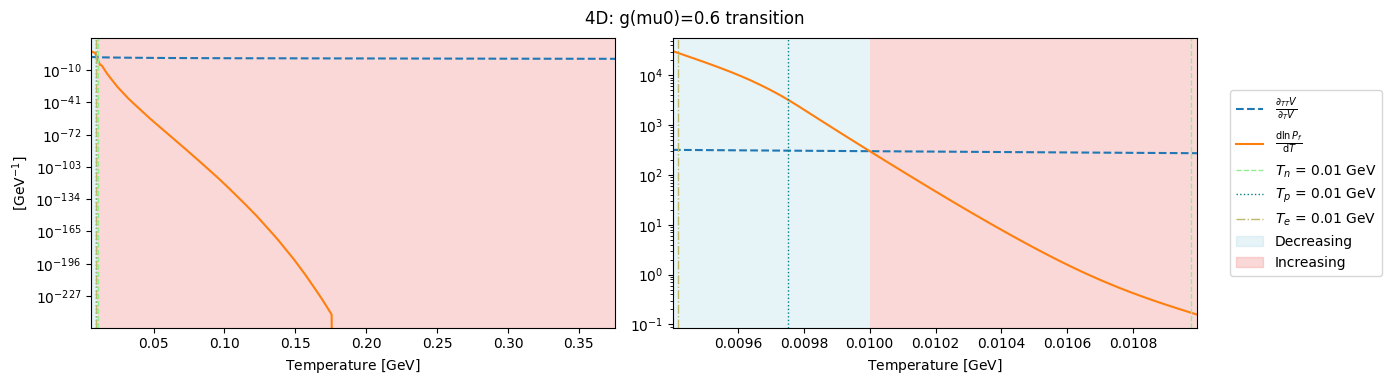

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Basic safety
Temps = np.asarray(Temps, dtype=float)
ratio_V = np.asarray(ratio_V, dtype=float)
d_dT_logP_f = np.asarray(d_dT_logP_f, dtype=float)
mask = np.asarray(mask, dtype=bool)

if len(Temps) < 2:
    raise RuntimeError("Not enough temperature points to make the volume-evolution plot.")

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full-range plot
axes[0].plot(Temps, ratio_V, label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[0].plot(Temps, d_dT_logP_f, label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(f"$\\mathrm{{[{units}^{{-1}}]}}$")

# Zoomed plot
axes[1].plot(Temps[mask], ratio_V[mask], label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[1].plot(Temps[mask], d_dT_logP_f[mask], label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# Legend patches
decreasing_patch = mpatches.Patch(color='lightblue', alpha=0.3, label='Decreasing')
increasing_patch = mpatches.Patch(color='lightcoral', alpha=0.3, label='Increasing')

# Find intersections between d_dT_logP_f and ratio_V
intersections = []
diff = d_dT_logP_f - ratio_V

for i in range(len(Temps) - 1):
    y1, y2 = diff[i], diff[i + 1]
    x1, x2 = Temps[i], Temps[i + 1]

    if not (np.isfinite(y1) and np.isfinite(y2) and np.isfinite(x1) and np.isfinite(x2)):
        continue

    # exact hit
    if y1 == 0:
        intersections.append(x1)

    # crossing
    elif y1 * y2 < 0:
        denom = (y2 - y1)
        if denom != 0:
            x_cross = x1 - y1 * (x2 - x1) / denom
            if np.isfinite(x_cross):
                intersections.append(x_cross)

# Add precise crossing points to define colored intervals
all_points = np.sort(np.unique(np.concatenate([Temps, np.array(intersections, dtype=float)])))

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")

    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}}$ = {T_completion:.2f} {units}')

    # Color intervals using midpoint test
    for i in range(len(all_points) - 1):
        x_left, x_right = all_points[i], all_points[i + 1]
        x_mid = 0.5 * (x_left + x_right)

        d_mid = np.interp(x_mid, Temps, d_dT_logP_f)
        r_mid = np.interp(x_mid, Temps, ratio_V)

        if np.isfinite(d_mid) and np.isfinite(r_mid):
            if d_mid >= r_mid:
                ax.axvspan(x_left, x_right, facecolor='lightblue', alpha=0.3)
            else:
                ax.axvspan(x_left, x_right, facecolor='lightcoral', alpha=0.3)

# Put the legend on the right panel
handles, labels = axes[1].get_legend_handles_labels()
handles.extend([decreasing_patch, increasing_patch])
labels.extend(['Decreasing', 'Increasing'])
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(f'{description} transition', y=0.95)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"volume_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

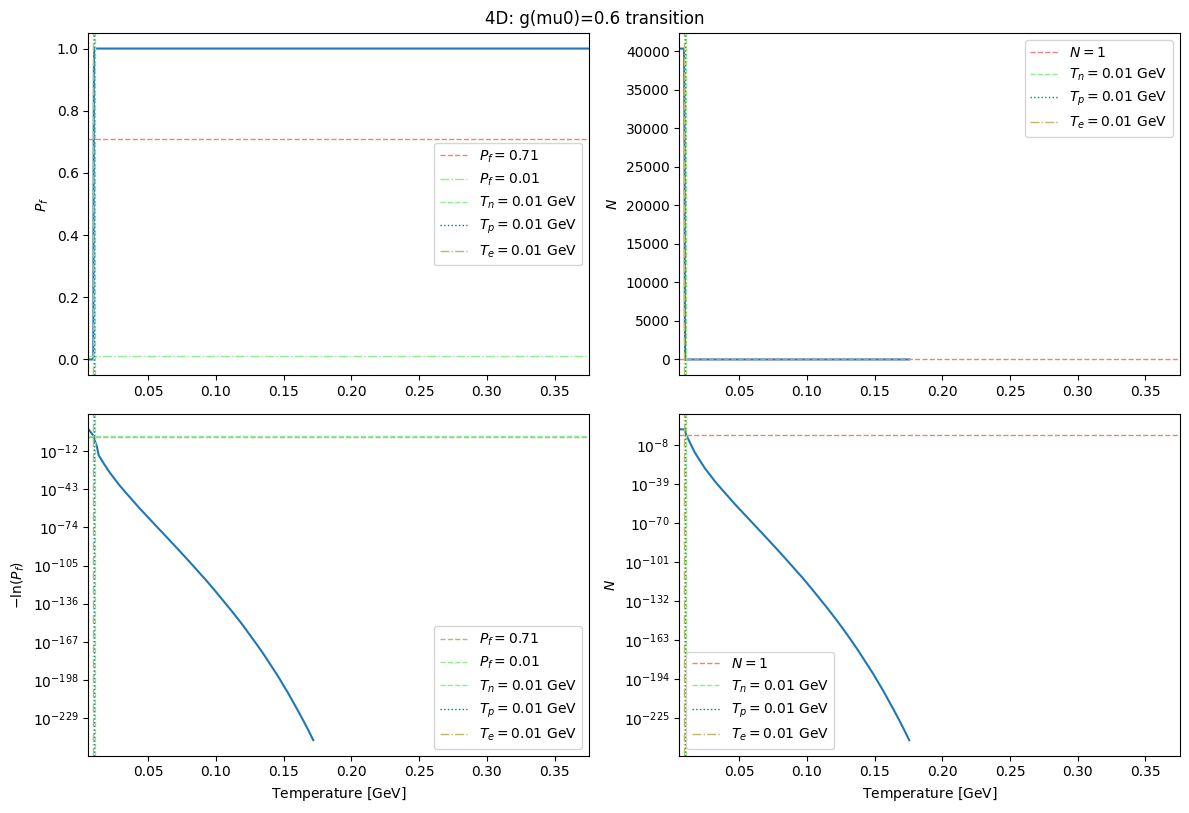

Average number of bubbles at T_min, N = 4.037e+04


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os

Temps = np.asarray(Temps, dtype=float)
logP_f = np.asarray(logP_f, dtype=float)
nH = np.asarray(nH, dtype=float)
mask_nH = np.asarray(mask_nH, dtype=bool)

Pf = np.exp(logP_f)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Pf
axes[0, 0].plot(Temps, Pf)
axes[0, 0].set_ylabel(r'$P_f$')
axes[0, 0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[0, 0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=r'$P_f = 0.01$')
axes[0, 0].legend()

# Top-right: N
if np.any(mask_nH):
    axes[0, 1].plot(Temps[mask_nH], nH[mask_nH])
axes[0, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[0, 1].set_ylabel(r'$N$')
axes[0, 1].legend()

# Bottom-left: -ln(Pf)
minus_logPf = -logP_f
mask_log = np.isfinite(minus_logPf) & (minus_logPf > 0)

if np.any(mask_log):
    axes[1, 0].plot(Temps[mask_log], minus_logPf[mask_log])

axes[1, 0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[1, 0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=r'$P_f = 0.01$')
axes[1, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 0].set_ylabel(r'$-\ln(P_f)$')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Bottom-right: N in log scale
mask_nH_log = np.isfinite(nH) & (nH > 0)
if np.any(mask_nH_log):
    axes[1, 1].plot(Temps[mask_nH_log], nH[mask_nH_log])
axes[1, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[1, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 1].set_ylabel(r'$N$')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# Milestone lines
for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\\ \\mathrm{{{units}}}$')
    ax.set_xlim(Temps[0], Temps[-1])
    ax.legend()

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"evolution_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

if np.any(mask_nH):
    print(f"Average number of bubbles at T_min, N = {nH[mask_nH][0]:.3e}")
else:
    print("Average number of bubbles at T_min, N = nan")

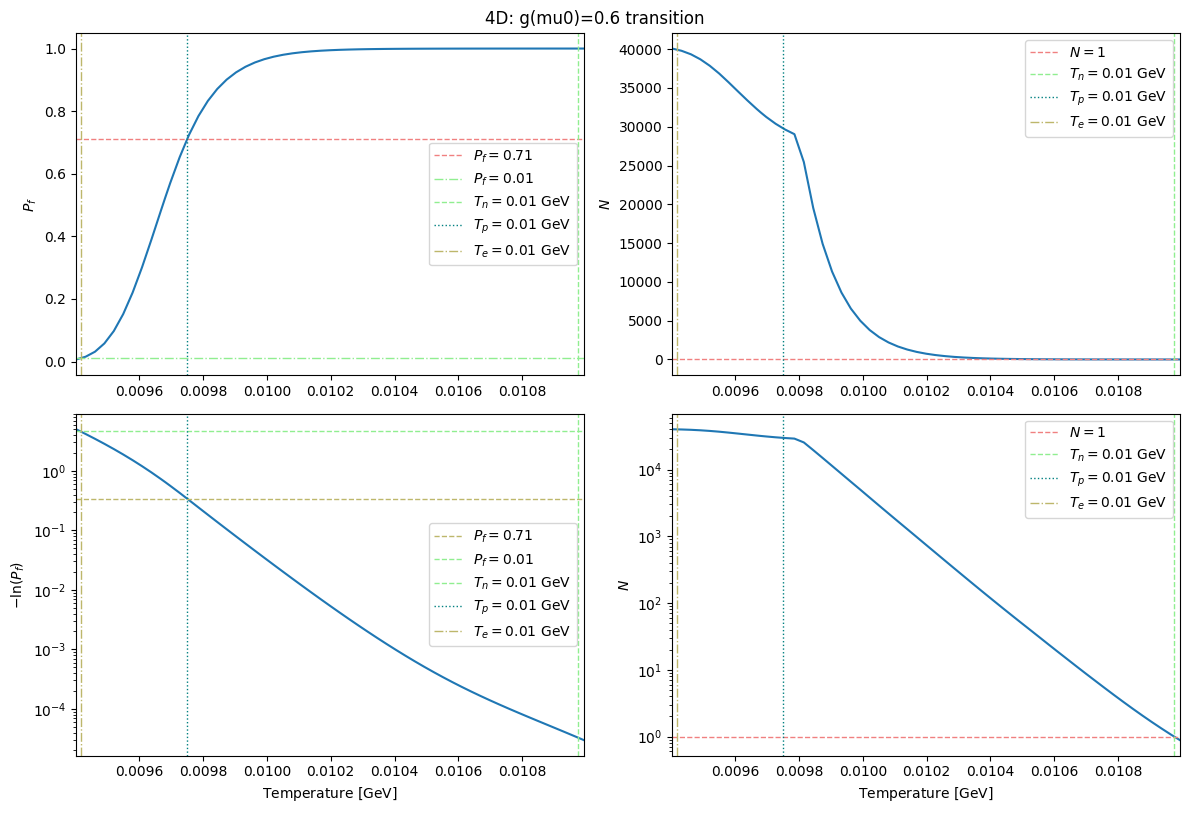

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os

Temps = np.asarray(Temps, dtype=float)
logP_f = np.asarray(logP_f, dtype=float)
nH = np.asarray(nH, dtype=float)
mask = np.asarray(mask, dtype=bool)

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

Temps_zoom = Temps[mask]
logP_f_zoom = logP_f[mask]
nH_zoom = nH[mask]
Pf_zoom = np.exp(logP_f_zoom)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Pf
axes[0, 0].plot(Temps_zoom, Pf_zoom)
axes[0, 0].set_ylabel(r'$P_f$')
axes[0, 0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[0, 0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=r'$P_f = 0.01$')
axes[0, 0].legend()

# Top-right: N
mask_zoom_nH = np.isfinite(nH_zoom)
if np.any(mask_zoom_nH):
    axes[0, 1].plot(Temps_zoom[mask_zoom_nH], nH_zoom[mask_zoom_nH])
axes[0, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[0, 1].set_ylabel(r'$N$')
axes[0, 1].legend()

# Bottom-left: -ln(Pf)
minus_logPf_zoom = -logP_f_zoom
mask_zoom_log = np.isfinite(minus_logPf_zoom) & (minus_logPf_zoom > 0)
if np.any(mask_zoom_log):
    axes[1, 0].plot(Temps_zoom[mask_zoom_log], minus_logPf_zoom[mask_zoom_log])
axes[1, 0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[1, 0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=r'$P_f = 0.01$')
axes[1, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 0].set_ylabel(r'$-\ln(P_f)$')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Bottom-right: N in log scale
mask_zoom_nH_log = np.isfinite(nH_zoom) & (nH_zoom > 0)
if np.any(mask_zoom_nH_log):
    axes[1, 1].plot(Temps_zoom[mask_zoom_nH_log], nH_zoom[mask_zoom_nH_log])
axes[1, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[1, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 1].set_ylabel(r'$N$')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# Milestone lines
for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\\ \\mathrm{{{units}}}$')
    ax.set_xlim(Temps_zoom[0], Temps_zoom[-1])
    ax.legend()

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"evolution_{description}_zoom.pdf"), dpi=300, bbox_inches='tight')

plt.show()

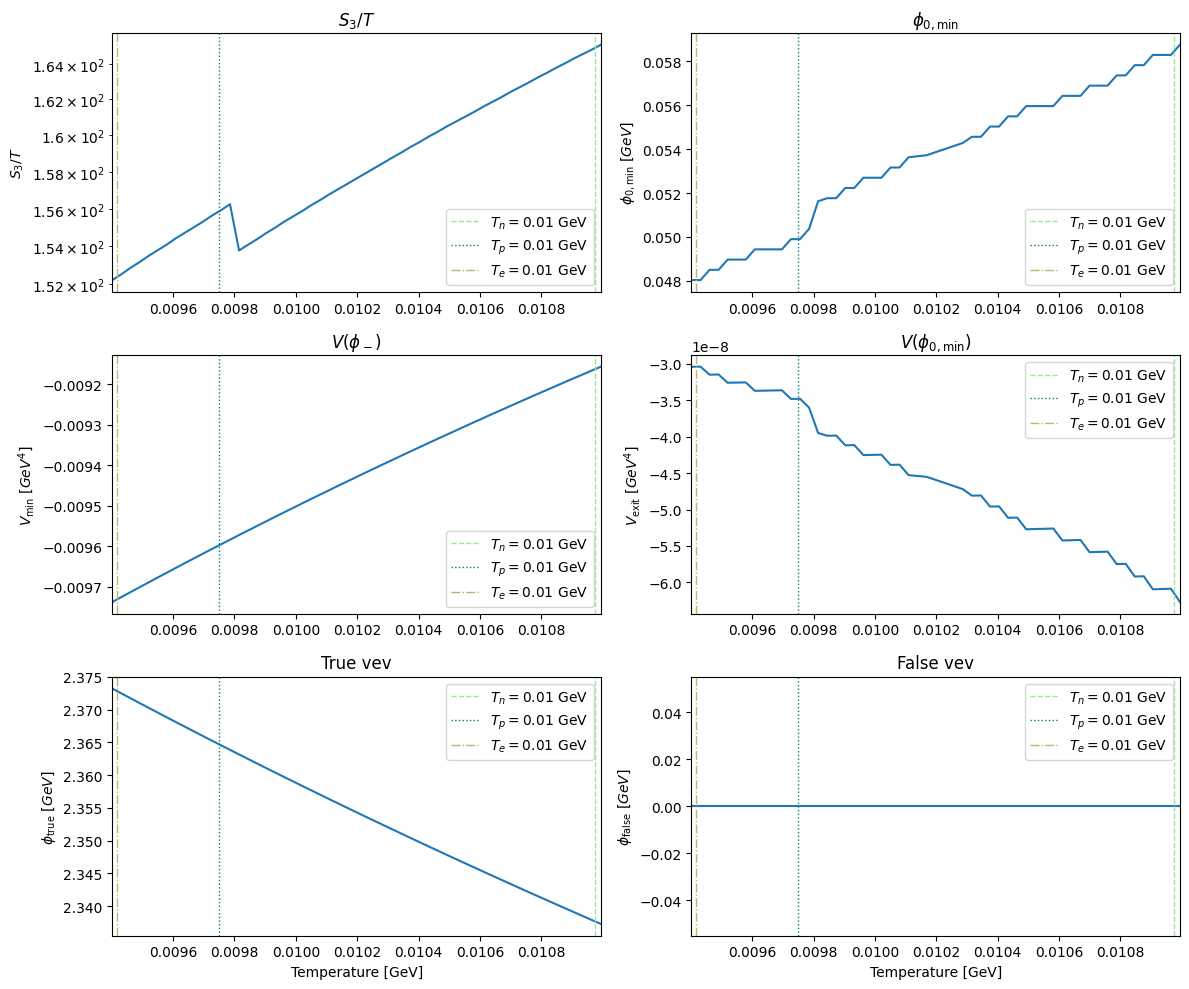

In [20]:
import numpy as np
import matplotlib.pyplot as plt

Temps = np.asarray(Temps, dtype=float)
mask = np.asarray(mask, dtype=bool)

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

Temps_zoom = Temps[mask]

# Keep only points that actually exist in the action dictionaries
Temps_zoom = np.array([T for T in Temps_zoom if T in S3overT], dtype=float)

if len(Temps_zoom) == 0:
    raise RuntimeError("No valid zoomed temperatures found in S3overT for plotting.")

S3_vals    = np.array([S3overT[T] for T in Temps_zoom], dtype=float)
phi0_vals  = np.array([phi0_min[T] for T in Temps_zoom], dtype=float)
Vmin_vals  = np.array([V_min_value[T] for T in Temps_zoom], dtype=float)
Vexit_vals = np.array([V_exit[T] for T in Temps_zoom], dtype=float)
true_vals  = np.array([true_vev[T] for T in Temps_zoom], dtype=float)
false_vals = np.array([false_vev[T] for T in Temps_zoom], dtype=float)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes[0, 0].plot(Temps_zoom, S3_vals)
axes[0, 0].set_title(r'$S_3/T$')
axes[0, 0].set_ylabel(r'$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(Temps_zoom, phi0_vals)
axes[0, 1].set_title(r'$\phi_{0,\mathrm{min}}$')
axes[0, 1].set_ylabel(f"$\\phi_{{0,\\mathrm{{min}}}}\\ [{units}]$")

axes[1, 0].plot(Temps_zoom, Vmin_vals)
axes[1, 0].set_title(r'$V(\phi_-)$')
axes[1, 0].set_ylabel(f"$V_{{\\mathrm{{min}}}}\\ [{units}^4]$")

axes[1, 1].plot(Temps_zoom, Vexit_vals)
axes[1, 1].set_title(r'$V(\phi_{0,\mathrm{min}})$')
axes[1, 1].set_ylabel(f"$V_{{\\mathrm{{exit}}}}\\ [{units}^4]$")

axes[2, 0].plot(Temps_zoom, true_vals)
axes[2, 0].set_title('True vev')
axes[2, 0].set_xlabel(f"Temperature [{units}]")
axes[2, 0].set_ylabel(f"$\\phi_{{\\mathrm{{true}}}}\\ [{units}]$")

axes[2, 1].plot(Temps_zoom, false_vals)
axes[2, 1].set_title('False vev')
axes[2, 1].set_xlabel(f"Temperature [{units}]")
axes[2, 1].set_ylabel(f"$\\phi_{{\\mathrm{{false}}}}\\ [{units}]$")

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\\ \\mathrm{{{units}}}$')
    ax.set_xlim(Temps_zoom[0], Temps_zoom[-1])
    ax.legend()

plt.tight_layout()
plt.show()

In [21]:
class ScalarSafeDP:
    def __init__(self, base):
        self.base = base

    def _X(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 0:
            return X.reshape(1, 1)
        if X.ndim == 1:
            return X.reshape(-1, 1)
        return X

    def Vtot(self, X, T, include_radiation=True):
        return self.base.Vtot(self._X(X), T,
                              include_radiation=include_radiation)

    def DVtot(self, X, T):
        return self.base.DVtot(self._X(X), T)

    def gradV(self, X, T):
        return self.base.gradV(self._X(X), T)

    def dVdT(self, X, T, include_radiation=True,
             include_SM=False, units="GeV"):          # ← fixed: pass all args
        return self.base.dVdT(
            self._X(X), T,
            include_radiation=include_radiation,
            include_SM=include_SM,                    # ← was silently dropped
            units=units,                              # ← was silently dropped
        )

    def d2VdT2(self, X, T, include_radiation=True,
               include_SM=False, units="GeV"):        # ← fixed: pass all args
        return self.base.d2VdT2(
            self._X(X), T,
            include_radiation=include_radiation,
            include_SM=include_SM,                    # ← was silently dropped
            units=units,                              # ← was silently dropped
        )

    def __getattr__(self, name):
        return getattr(self.base, name)

In [22]:
dp_safe = ScalarSafeDP(dp)

In [23]:
from GWparams import cs2
import numpy as np
import matplotlib.pyplot as plt

def vev_at_T(true_vev_dict, T):
    T = float(T)
    closest_key = min(true_vev_dict.keys(), key=lambda k: abs(k - T))
    return float(true_vev_dict[closest_key])

# Proxy dict that does nearest-key lookup instead of exact match
class NearestKeyDict:
    def __init__(self, d):
        self._d = d
        self._keys = np.array(sorted(d.keys()))

    def __getitem__(self, T):
        idx = np.argmin(np.abs(self._keys - float(T)))
        return float(self._d[self._keys[idx]])

    def __getattr__(self, name):
        return getattr(self._d, name)

true_vev_safe = NearestKeyDict(true_vev)

if T_perc is not None and np.isfinite(T_perc):
    action_over_T(T_perc)
    c_s2 = cs2(float(T_perc), dp_safe, true_vev_safe, units=units)
    print(f"c_s^2(T_perc) = {c_s2}")

y = np.array([
    cs2(float(T), dp_safe, true_vev_safe, units=units)
    for T in Temps
], dtype=float)

/tmp/ipykernel_3463/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


c_s^2(T_perc) = [-0.81186346]


In [24]:
# Drop-in replacement for cs2 that is safe in the supercooled regime:
def cs2_safe(T, m, true_vev, units='GeV'):
    T    = float(T)
    v_t  = float(np.asarray(true_vev[T]).squeeze())

    dVdT_val   = float(np.asarray(
        m.dVdT(v_t,   T, include_radiation=True, include_SM=True, units=units)
    ).squeeze())
    d2VdT2_val = float(np.asarray(
        m.d2VdT2(v_t, T, include_radiation=True, include_SM=True, units=units)
    ).squeeze())

    denom = T * d2VdT2_val

    # If denominator is zero or ratio is unphysical, fall back to 1/3
    if abs(denom) < 1e-30 or d2VdT2_val >= 0.0:
        return 1.0 / 3.0

    speed2 = dVdT_val / denom

    # Physical range is (0, 1/3] — clamp both sides
    if speed2 <= 0.0 or not np.isfinite(speed2):
        return 1.0 / 3.0

    return min(1.0 / 3.0, speed2)


# Verify:
cs2_val = cs2_safe(float(T_perc), dp_safe, true_vev, units)
print(f"cs2_safe = {cs2_val:.6f}")

cs2_safe = 0.333333


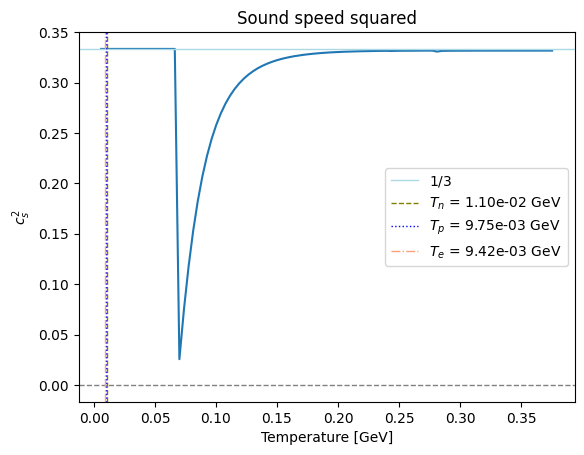

In [25]:
y = np.array([
    cs2_safe(T, dp_safe, true_vev_safe, units=units)
    for T in Temps
], dtype=float)

plt.plot(Temps, y)
plt.axhline(1/3, color='lightblue', linewidth=1, label=r'$1/3$')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

if np.isfinite(T_nuc):
    plt.axvline(T_nuc, color='olive', linestyle='--', linewidth=1, label=fr'$T_n$ = {T_nuc:.2e} {units}')
if np.isfinite(T_perc):
    plt.axvline(T_perc, color='blue', linestyle=':', linewidth=1, label=fr'$T_p$ = {T_perc:.2e} {units}')
if np.isfinite(T_completion):
    plt.axvline(T_completion, color='lightsalmon', linestyle='-.', linewidth=1, label=fr'$T_e$ = {T_completion:.2e} {units}')

plt.title(r'Sound speed squared')
plt.xlabel(f'Temperature [{units}]')
plt.ylabel(r'$c_s^2$')
plt.legend()
plt.show()

In [26]:
import numpy as np

def scalar(x):
    return float(np.asarray(x).squeeze())

def alpha_th_bar_safe(T, m, V_min_value, false_vev, true_vev, units='GeV'):
    T     = float(T)
    v_t   = scalar(true_vev[T])
    v_f   = scalar(false_vev[T])
    Vmin  = scalar(V_min_value[T])

    cs2_val = cs2_safe(T, m, true_vev, units)   # clamped to (0, 1/3]

    dVdT_f    = scalar(m.dVdT(v_f, T, include_radiation=True, include_SM=False, units=units))
    dVdT_t    = scalar(m.dVdT(v_t, T, include_radiation=True, include_SM=False, units=units))
    dVdT_f_SM = scalar(m.dVdT(v_f, T, include_radiation=True, include_SM=True,  units=units))

    delta_rho = -Vmin - T * (dVdT_f - dVdT_t)
    delta_p   =  Vmin / cs2_val

    wf    = -T * dVdT_f_SM   # total (SM + DS)
    wf_DS = -T * dVdT_f      # dark sector only

    return (delta_rho - delta_p) / (3.0 * wf), (delta_rho - delta_p) / (3.0 * wf_DS)


def c_alpha_inf(T, units):
    T = float(T)
    v_true  = scalar(true_vev[T])
    v_false = scalar(false_vev[T])

    gT2, lamT, _ = dp_safe.run_params(dp_safe.mu_eff(T))

    Dm2_photon = 3.0 * gT2  * (v_true**2 - v_false**2)
    Dm2_scalar = 3.0 * lamT * (v_true**2 - v_false**2)
    numerator  = (Dm2_photon + Dm2_scalar) * T**2 / 24.0

    rho_tot = -0.75 * T * scalar(
        dp_safe.dVdT(v_false, T, include_radiation=True, include_SM=True,  units=units)
    )
    rho_DS  = -0.75 * T * scalar(
        dp_safe.dVdT(v_false, T, include_radiation=True, include_SM=False, units=units)
    )

    return numerator / rho_tot, numerator / rho_DS


def c_alpha_eq(T, units):
    T = float(T)
    v_true  = scalar(true_vev[T])
    v_false = scalar(false_vev[T])

    gT2, _, _ = dp_safe.run_params(dp_safe.mu_eff(T))
    gT        = np.sqrt(gT2)
    numerator = 3.0 * gT2 * gT * abs(v_true - v_false) * T**3

    rho_tot = -0.75 * T * scalar(
        dp_safe.dVdT(v_false, T, include_radiation=True, include_SM=True,  units=units)
    )
    rho_DS  = -0.75 * T * scalar(
        dp_safe.dVdT(v_false, T, include_radiation=True, include_SM=False, units=units)
    )

    return numerator / rho_tot, numerator / rho_DS


# ── Replace the alpha_th_bar call ────────────────────────────────────────
alpha, alpha_DS = alpha_th_bar_safe(
    float(T_perc),
    dp_safe,
    V_min_value,
    false_vev,
    true_vev,
    units=units,
)

alpha    = scalar(alpha)
alpha_DS = scalar(alpha_DS)

alpha_inf, alpha_inf_DS = c_alpha_inf(T_perc, units)
alpha_eq,  alpha_eq_DS  = c_alpha_eq(T_perc, units)

gamma_eq = (alpha - alpha_inf) / alpha_eq

print(f"alpha     = {alpha:.4f}")
print(f"alpha_inf = {alpha_inf:.4f}")
print(f"alpha_eq  = {alpha_eq:.4f}")
print(f"gamma_eq  = {gamma_eq:.4f}")

is_physical = True

if alpha < alpha_inf:
    is_physical = False
    print("\n*** Warning: bubble expansion not in runaway regime ***")

v_min     = 0.99
gamma_min = 1.0 / np.sqrt(1.0 - v_min**2)
if gamma_eq < gamma_min:
    is_physical = False
    print(f"\n*** Warning: gamma_eq = {gamma_eq:.2e} — walls may not reach relativistic velocities ***")

alpha     = 31740.6082
alpha_inf = 68.0081
alpha_eq  = 4.2401
gamma_eq  = 7469.8538


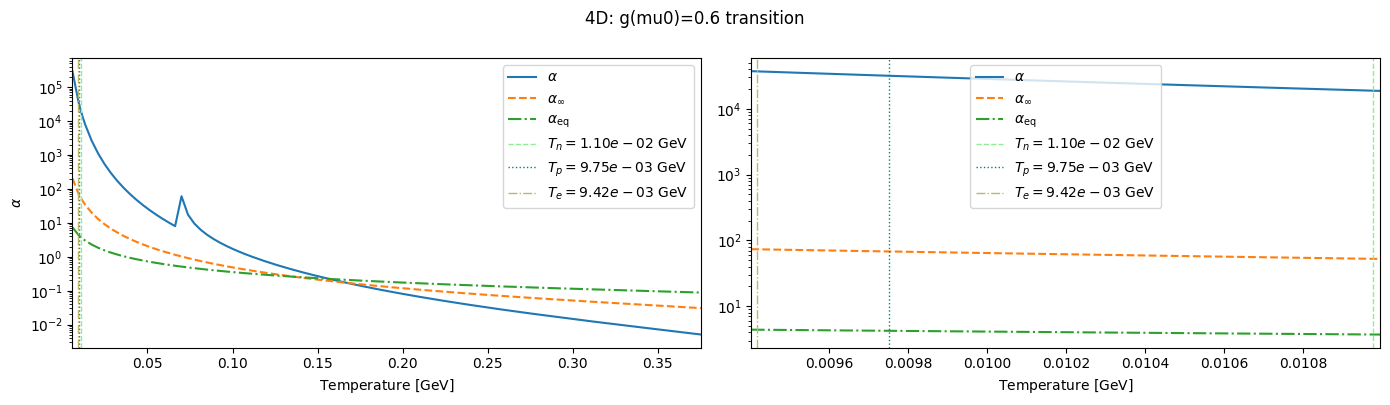

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os

def scalar(x):
    return float(np.asarray(x).squeeze())

alpha_T = np.array([
    scalar(alpha_th_bar_safe(float(T), dp_safe, V_min_value, false_vev, true_vev, units=units)[0])
    for T in Temps
], dtype=float)

alpha_inf_T = np.array([
    scalar(c_alpha_inf(float(T), units)[0])
    for T in Temps
], dtype=float)

alpha_eq_T = np.array([
    scalar(c_alpha_eq(float(T), units)[0])
    for T in Temps
], dtype=float)

mask = np.asarray(mask, dtype=bool)
if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, alpha_T, label=r'$\alpha$', linestyle='-')
axes[0].plot(Temps, alpha_inf_T, label=r'$\alpha_\infty$', linestyle='--')
axes[0].plot(Temps, alpha_eq_T, label=r'$\alpha_{\mathrm{eq}}$', linestyle='-.')
axes[0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[0].set_ylabel(r'$\alpha$')
axes[0].set_yscale('log')
axes[0].set_xlim(Temps[0], Temps[-1])

axes[1].plot(Temps[mask], alpha_T[mask], label=r'$\alpha$', linestyle='-')
axes[1].plot(Temps[mask], alpha_inf_T[mask], label=r'$\alpha_\infty$', linestyle='--')
axes[1].plot(Temps[mask], alpha_eq_T[mask], label=r'$\alpha_{\mathrm{eq}}$', linestyle='-.')
axes[1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

positive_zoom = np.concatenate([
    alpha_T[mask],
    alpha_inf_T[mask],
    alpha_eq_T[mask],
])
positive_zoom = positive_zoom[np.isfinite(positive_zoom) & (positive_zoom > 0)]

if len(positive_zoom) > 0:
    if np.nanmin(positive_zoom) > 0 and np.nanmax(positive_zoom) / np.nanmin(positive_zoom) > 5:
        axes[1].set_yscale('log')

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$T_n = {T_nuc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=fr'$T_p = {T_perc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=fr'$T_e = {T_completion:.2e}\ \mathrm{{{units}}}$')
    ax.legend()

fig.suptitle(f'{description} transition', y=1.00)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"alpha_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

In [29]:
from temperatures import R_sepH

RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
RH_interp = interpolation_narrow(Temps, RH, T_perc)
H_star = interpolation_narrow(Temps, H, T_perc)
R_star = RH_interp / H_star

print(f"R* H* = {RH_interp:.2e}")

R* H* = 5.30e-02


/content/ELENA/src/temperatures.py:433: RuntimeWarning: divide by zero encountered in power
  return n**(-1/3) * H, n**(-1/3)


<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence

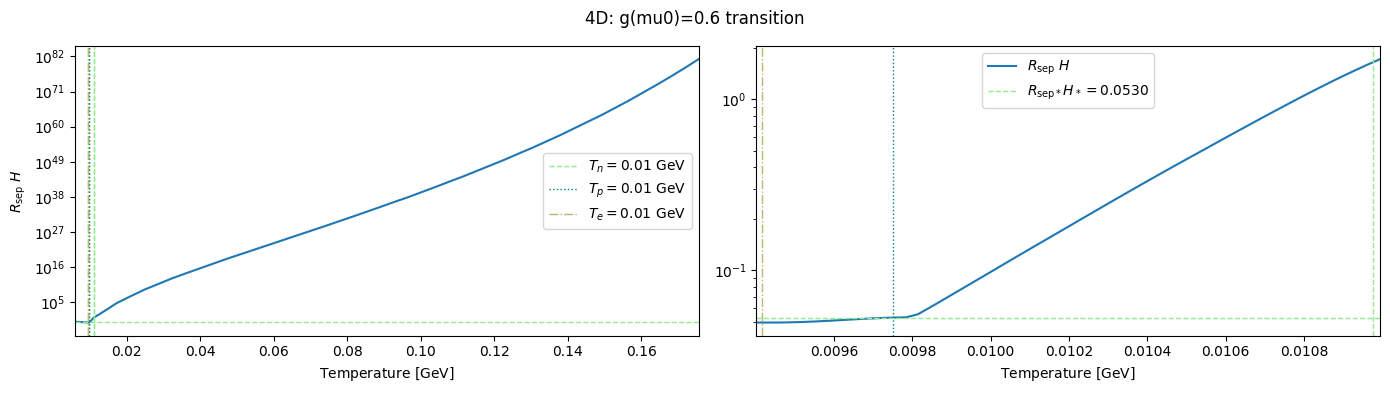

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, RH) #, label = '$R H$')
axes[0].set_ylabel('$R_\mathrm{sep}\ H$')
axes[0].set_yscale('log')
axes[0].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1) #, label=f'$R_* H_* = {RH_interp:.4f}$')
axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}} = {T_nuc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}} = {T_perc:.2f} \mathrm{{\ {units}}}$')
axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}} = {T_completion:.2f} \mathrm{{\ {units}}}$')
axes[0].set_xlim(Temps[0], Temps[np.max(np.where(RH < np.inf)[0])])
axes[0].legend()

axes[1].plot(Temps[mask], RH[mask], label = '$R_\mathrm{sep}\ H$')
#axes[1].set_ylabel('$R\ H$')
axes[1].set_yscale('log')
axes[1].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1, label=f'$R_\mathrm{{sep *}} H_* = {RH_interp:.4f}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])
axes[1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'$T_{{n}}$ = {T_nuc:.2e} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'$T_{{p}}$ = {T_perc:.2e} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'$T_{{e}}$ = {T_completion:.2e} {units}')
    ax.set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")

# handles, labels = axes[1].get_legend_handles_labels()
# axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

#fig.suptitle(f'Mean bubble separation - {description}')
fig.suptitle(f'{description} transition', y=0.97)
plt.savefig(figure_dir + f"RH_{description}.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [31]:
T_perc

np.float64(0.009750471628519828)

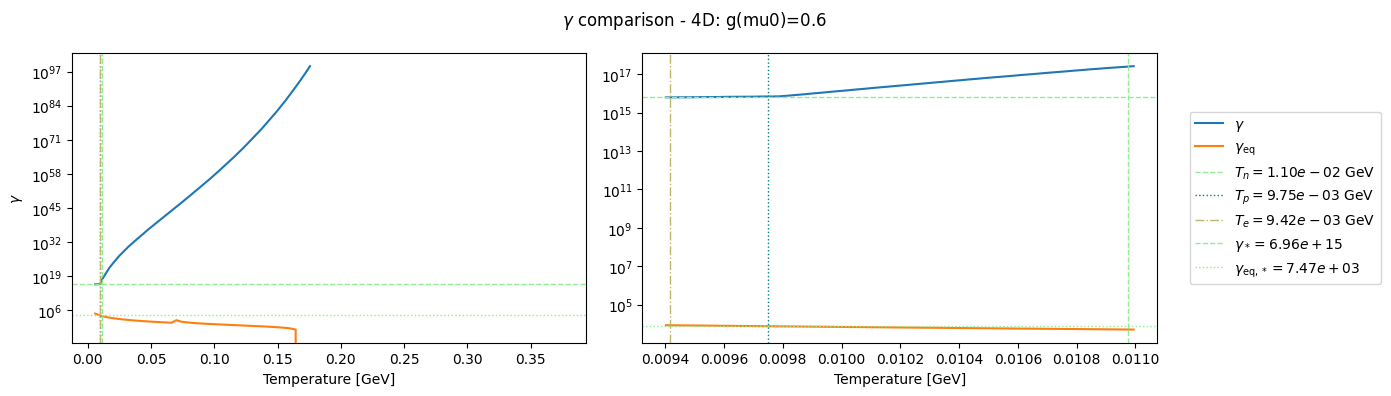

In [32]:
from utils import interpolation_narrow
import numpy as np
import matplotlib.pyplot as plt

def scalar(x):
    return float(np.asarray(x).squeeze())

def R0_safe(T, S3_T, V_exit):
    T = float(T)
    E0V = scalar(S3_T[T]) * T
    DV = -scalar(V_exit[T])
    if DV <= 0 or not np.isfinite(DV):
        return np.nan
    return (3.0 * E0V / (4.0 * np.pi * DV))**(1.0 / 3.0)

r0 = np.array([
    R0_safe(float(T), S3overT, V_exit)
    for T in Temps
], dtype=float)

gamma_eq_T = (alpha_T - alpha_inf_T) / alpha_eq_T

R = np.asarray(R, dtype=float)
gamma = 2.0 * R / (3.0 * r0)

R_star = scalar(interpolation_narrow(Temps, R, T_perc))
r0_star = R0_safe(float(T_perc), S3overT, V_exit)

gamma_star = 2.0 * R_star / (3.0 * r0_star)
gamma_eq_star = scalar(interpolation_narrow(Temps, gamma_eq_T, T_perc))

mask = np.asarray(mask, dtype=bool)
if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Temps, gamma, label=r'$\gamma$')
axes[0].plot(Temps, gamma_eq_T, label=r'$\gamma_{\mathrm{eq}}$')
axes[0].set_yscale('log')
axes[0].set_xlabel(f'Temperature [{units}]')
axes[0].set_ylabel(r'$\gamma$')

axes[1].plot(Temps[mask], gamma[mask], label=r'$\gamma$')
axes[1].plot(Temps[mask], gamma_eq_T[mask], label=r'$\gamma_{\mathrm{eq}}$')
axes[1].set_yscale('log')
axes[1].set_xlabel(f'Temperature [{units}]')

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$T_n = {T_nuc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=fr'$T_p = {T_perc:.2e}\ \mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=fr'$T_e = {T_completion:.2e}\ \mathrm{{{units}}}$')

    if np.isfinite(gamma_star):
        ax.axhline(gamma_star, color='lightgreen', linestyle='--', linewidth=1,
                   label=fr'$\gamma_* = {gamma_star:.2e}$')
    if np.isfinite(gamma_eq_star):
        ax.axhline(gamma_eq_star, color='lightgreen', linestyle=':', linewidth=1,
                   label=fr'$\gamma_{{\mathrm{{eq}},*}} = {gamma_eq_star:.2e}$')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(fr'$\gamma$ comparison - {description}')
plt.tight_layout()
plt.show()

In [33]:
from GWparams import beta
import temperatures as temp # Import the temperatures module to access compute_logP_f

logP_f, Temps, ratio_V, Gamma, H = temp.compute_logP_f(dp, V_min_value, S3overT, v_w = 1, units = units, cum_method= 'None')

beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_nuc, T_perc, verbose = True)

# delta = (T_nuc - T_perc) / 2
# beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_perc + delta, T_perc - delta, verbose = True)

print("beta =", beta_Hn)
print("gamma =", gamma_Hn)

beta = 107.02415124640457
gamma = 19.42897387119983


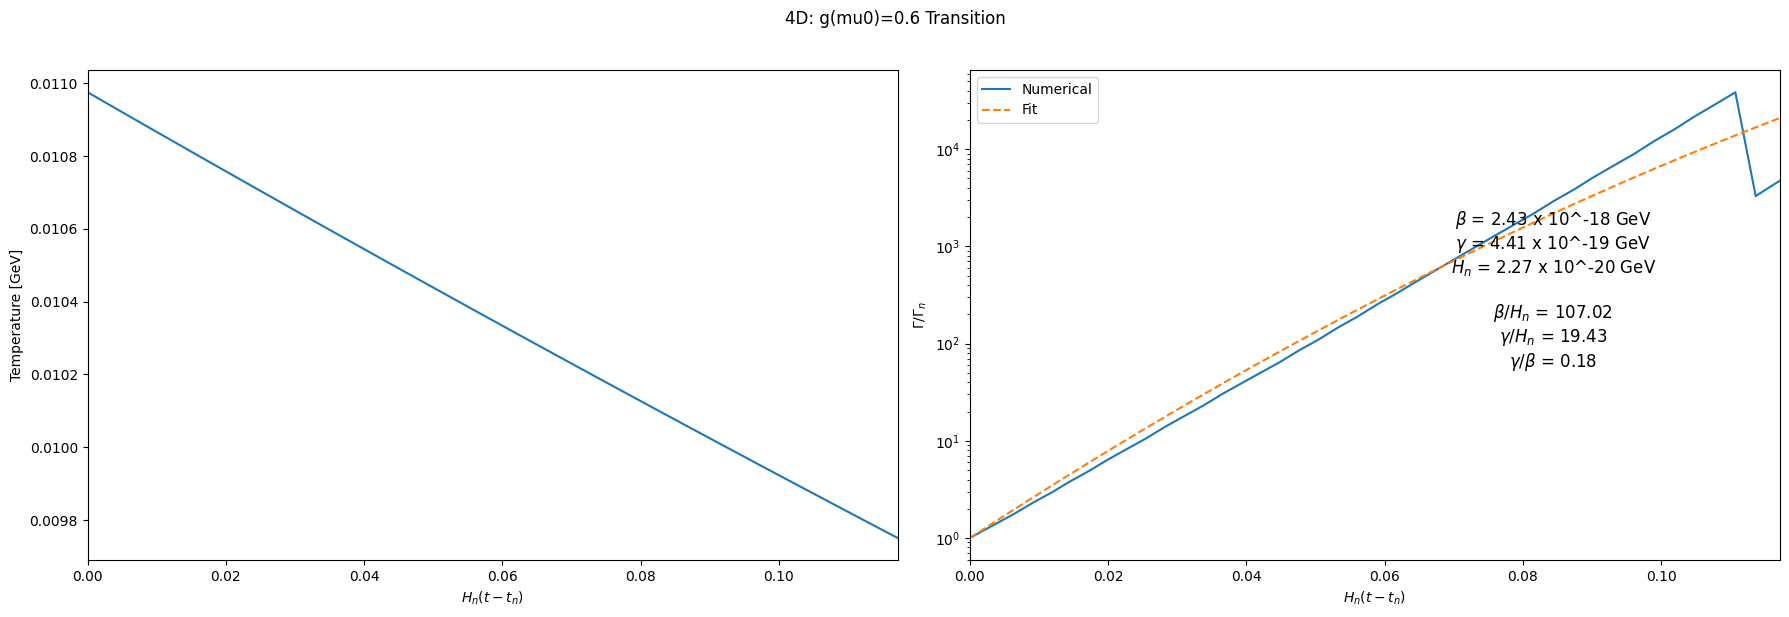

Percolation at 1.17e-01


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['text.usetex'] = False

if len(times) == 0 or len(Gamma_t) == 0 or len(Temps_t) == 0 or len(H_t) == 0:
    raise RuntimeError("beta(...) returned empty arrays, so the nucleation-fit plot cannot be made.")

Gamma_n = float(Gamma_t[0])
H_n = float(H_t[0])

def scientific_notation(number):
    """Return a string in scientific notation for display."""
    number = float(number)
    if not np.isfinite(number) or number == 0.0:
        return "0"
    exponent = int(np.floor(np.log10(abs(number))))
    coefficient = number / (10 ** exponent)
    return f"{coefficient:.2f} x 10^{exponent}"

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# -------- temperature evolution --------
axes[0].plot(times, Temps_t)
axes[0].set_xlabel(r"$H_n (t - t_n)$")
axes[0].set_ylabel(f"Temperature [{units}]")
axes[0].set_xlim(times[0], times[-1])

# -------- parameter box text --------
beta_dim = beta_Hn * H_n if np.isfinite(beta_Hn) and np.isfinite(H_n) else np.nan
gamma_dim = gamma_Hn * H_n if np.isfinite(gamma_Hn) and np.isfinite(H_n) else np.nan
gamma_over_beta = gamma_Hn / beta_Hn if np.isfinite(gamma_Hn) and np.isfinite(beta_Hn) and beta_Hn != 0 else np.nan

box_text = (
    f"$\\beta$ = {scientific_notation(beta_dim)} {units}\n"
    f"$\\gamma$ = {scientific_notation(gamma_dim)} {units}\n"
    f"$H_n$ = {scientific_notation(H_n)} {units}\n\n"
    f"$\\beta / H_n$ = {beta_Hn:.2f}\n"
    f"$\\gamma / H_n$ = {gamma_Hn:.2f}\n"
    f"$\\gamma / \\beta$ = {gamma_over_beta:.2f}" if np.isfinite(gamma_over_beta)
    else
    f"$\\beta / H_n$ = {beta_Hn:.2f}\n"
    f"$\\gamma / H_n$ = {gamma_Hn:.2f}\n"
    f"$\\gamma / \\beta$ = nan"
)

# -------- Gamma/Gamma_n and fit --------
mask_gamma_plot = np.isfinite(Gamma_t) & (Gamma_t > 0)
if np.any(mask_gamma_plot):
    axes[1].plot(times[mask_gamma_plot], Gamma_t[mask_gamma_plot] / Gamma_n, label="Numerical")

tfit = np.linspace(times[0], times[-1], 200, endpoint=True)
fit_curve = np.exp(beta_Hn * tfit - (gamma_Hn * tfit) ** 2 / 2.0)
fit_curve[~np.isfinite(fit_curve)] = np.nan
fit_curve[fit_curve <= 0] = np.nan
axes[1].plot(tfit, fit_curve, label="Fit", linestyle='--')

axes[1].set_xlabel(r"$H_n (t - t_n)$")
axes[1].set_ylabel(r"$\Gamma / \Gamma_n$")
axes[1].set_yscale('log')
axes[1].set_xlim(times[0], times[-1])

# Put text box inside right panel
axes[1].text(
    0.72, 0.55,
    box_text,
    fontsize='large',
    transform=axes[1].transAxes,
    horizontalalignment='center',
    verticalalignment='center'
)

axes[1].legend()

plt.suptitle(f'{description} Transition', y=1.02)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"nucleation_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

print(f"Percolation at {times[-1]:.2e}")

In [35]:
from google.colab import files

uploaded = files.upload()

Saving NG15.pkl to NG15.pkl


In [36]:
import matplotlib.pyplot as plt

plt.ion()          # re-enable interactive plotting
plt.close("all")   # clean broken figures


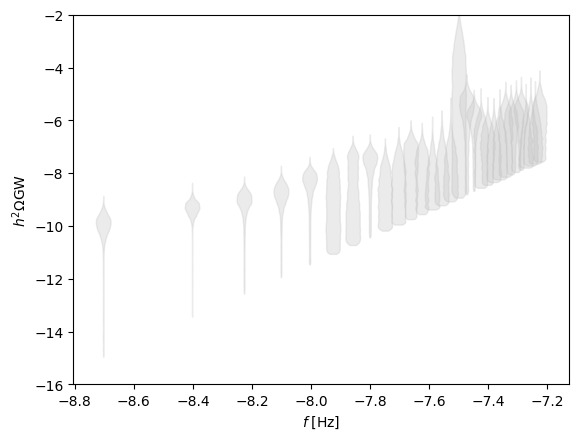

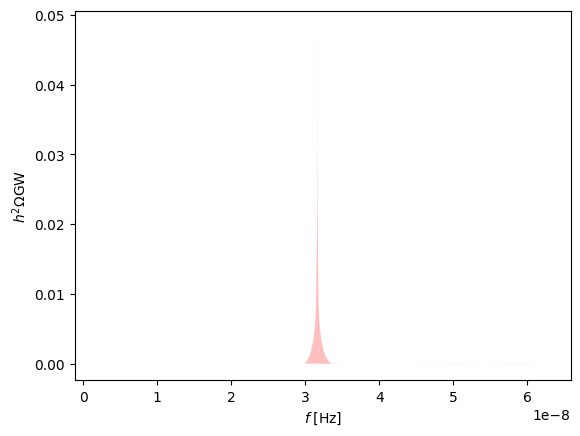

In [37]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pkl_path = "NG15.pkl"

with open(pkl_path, "rb") as f:
    fig, ax = pickle.load(f)

fig_linear, ax_linear = plt.subplots(figsize=fig.get_size_inches())

for collection in ax.collections:
    if hasattr(collection, "get_paths") and len(collection.get_paths()) > 0:
        path = collection.get_paths()[0]
        vertices = path.vertices

        if len(vertices) > 0:
            x_log = vertices[:, 0]
            y_log = vertices[:, 1]

            x_linear = 10**x_log
            y_linear = 10**y_log

            ax_linear.fill(
                x_linear,
                y_linear,
                facecolor="red",        # <-- force red
                edgecolor="none",       # cleaner for papers
                alpha=0.25,             # good transparency
            )

ax_linear.set_xscale("linear")
ax_linear.set_yscale("linear")
ax_linear.set_xlabel(ax.get_xlabel())
ax_linear.set_ylabel(ax.get_ylabel())
ax_linear.set_title(ax.get_title())

plt.show()




In [38]:
x=(alpha+1)**(1/4)

In [39]:
T_reh=x*T_perc

Is physical? True
lambda(mu0) = 0.0
g(mu0) = 0.6
vev = 1.0 GeV
m_phi = 0.0 GeV
m_Z = 0.6 GeV
T_crit = 0.37550000000000777 GeV
T_nuc = 0.010975201360254925 GeV
T_perc = 0.009750471628519828 GeV
T_completion = 0.009416633388523868 GeV
T_min = 0.0021389220519981633 GeV
T_reh = 0.1301466083370721 GeV
Minimal value of P_f = 0.0
alpha = 31740.6082353392
alpha_inf = 68.00811821436731
alpha_eq = 4.240056249613234
gamma_* = 6959926986795603.0
gamma_eq = 7469.853759608477
Is runaway? True
RH = 0.05297825492565472


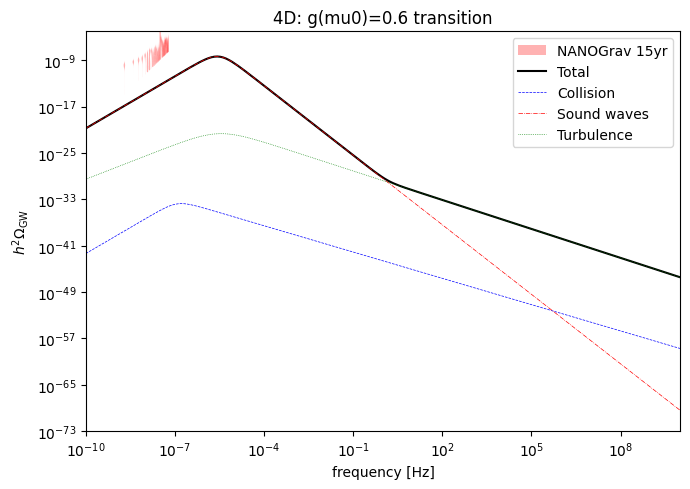

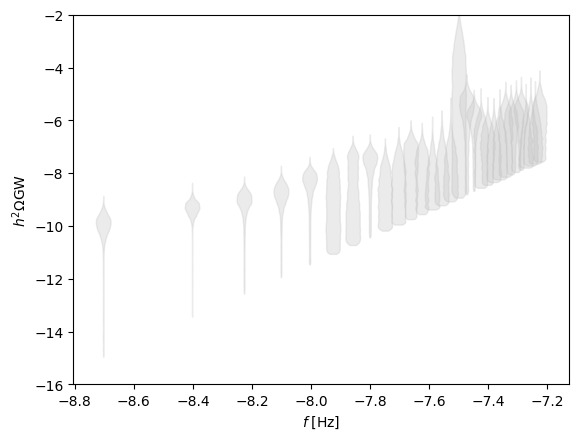

In [40]:
import pickle
import contextlib
import os
import numpy as np
import matplotlib.pyplot as plt
from GWparams import GW_SuperCooled

os.makedirs(figure_dir, exist_ok=True)

# Safer sound speed choice for this supercooled benchmark
c_s2_GW = 1.0 / 3.0

# Paper benchmark names
lambdaf = lambda_0
gX = g
m_phi = np.sqrt(max(2.0 * lambdaf, 0.0)) * vev
m_Z = gX * vev

def scalar(x):
    return float(np.asarray(x).squeeze())

alpha_plot     = abs(alpha)
alpha_inf_plot = abs(alpha_inf)
alpha_eq_plot  = abs(alpha_eq)
gamma_star = scalar(gamma_star)
gamma_eq = scalar(gamma_eq)

def safe_print(name, value, unit=""):
    print(f"{name} = {value} {unit}".strip())

def print_params():
    print(f"Is physical? {is_physical}")
    safe_print("lambda(mu0)", lambdaf)
    safe_print("g(mu0)", gX)
    safe_print("vev", vev, units)
    safe_print("m_phi", m_phi, units)
    safe_print("m_Z", m_Z, units)
    safe_print("T_crit", T_max, units)
    safe_print("T_nuc", T_nuc, units)
    safe_print("T_perc", T_perc, units)
    safe_print("T_completion", T_completion, units)
    safe_print("T_min", T_min, units)

    if "T_reh" in globals():
        safe_print("T_reh", T_reh, units)

    print(f"Minimal value of P_f = {np.nanmin(np.exp(logP_f))}")
    print(f"alpha = {alpha}")
    print(f"alpha_inf = {alpha_inf}")
    print(f"alpha_eq = {alpha_eq}")
    print(f"gamma_* = {gamma_star}")
    print(f"gamma_eq = {gamma_eq}")
    print(f"Is runaway? {alpha > alpha_inf}")

    if "R_star" in globals() and "H_star" in globals():
        print(f"RH = {R_star * H_star}")

# Save parameters
with open(os.path.join(figure_dir, f"{description}.txt"), "w") as f:
    with contextlib.redirect_stdout(f):
        print_params()

log_freq_min = -10
log_freq_max = 10

# Check if alpha is valid for T_reh calculation before proceeding
if T_perc is not None and np.isfinite(T_perc):

    inst = GW_SuperCooled(
        float(T_perc),
        alpha,
        alpha_inf,
        alpha_eq,
        scalar(R_star),
        gamma_star,
        scalar(H_star),
        c_s=np.sqrt(c_s2_GW),
        units=units,
    )

    print_params()

    freq = np.logspace(log_freq_min, log_freq_max, 200)

    fig_linear, ax_linear = plt.subplots(figsize=(7, 5))

    # -------------------------
    # Load and plot NANOGrav 15yr
    # -------------------------
    ng_file = "NG15.pkl"

    if os.path.exists(ng_file):
        try:
            with open(ng_file, "rb") as f:
                # Load the pickled matplotlib Figure and its Axes
                ng_fig, ng_ax = pickle.load(f)

            first_collection = True
            # Extract data from the collections of the loaded NANOGrav figure
            # Assuming the NANOGrav signal is represented by fill_between
            for collection in ng_ax.collections:
                if hasattr(collection, "get_paths") and len(collection.get_paths()) > 0:
                    path = collection.get_paths()[0]
                    vertices = path.vertices

                    if len(vertices) > 0:
                        x_log = vertices[:, 0]
                        y_log = vertices[:, 1]

                        x_linear = 10**x_log
                        y_linear = 10**y_log

                        label = "NANOGrav 15yr" if first_collection else None
                        ax_linear.fill(
                            x_linear,
                            y_linear,
                            facecolor="red",
                            edgecolor="none",
                            alpha=0.3,
                            label=label,
                        )
                        first_collection = False

            # Also try to plot any lines found in the NG15 figure (e.g., median line)
            for line in ng_ax.lines:
                x_line = line.get_xdata()
                y_line = line.get_ydata()
                if len(x_line) > 0 and len(y_line) > 0:
                    ax_linear.plot(x_line, y_line, linewidth=1, color="red", alpha=0.7, label=None)

        except Exception as e:
            print(f"Could not load or plot NANOGrav data from {ng_file}: {e}")
    else:
        print(f"NANOGrav file not found: {ng_file}")

    # -------------------------
    # Plot GW spectrum
    # -------------------------
    ax_linear.plot(freq, inst.Omegah2(freq), label="Total", color="black")
    ax_linear.plot(freq, inst.Omegah2coll(freq), label="Collision", linewidth=0.5, color="blue", linestyle="--")
    ax_linear.plot(freq, inst.Omegah2sw(freq), label="Sound waves", linewidth=0.5, color="red", linestyle="-.")
    ax_linear.plot(freq, inst.Omegah2turb(freq), label="Turbulence", linewidth=0.5, color="green", linestyle=":")

    ax_linear.set_xlim(freq[0], freq[-1])
    ax_linear.set_ylim(1e-73, 1e-4)
    ax_linear.set_xscale("log")
    ax_linear.set_yscale("log")
    ax_linear.set_xlabel("frequency [Hz]")
    ax_linear.set_ylabel(r"$h^2\Omega_{\rm GW}$")
    ax_linear.legend()
    ax_linear.set_title(f"{description} transition")

    fig_linear.tight_layout()
    fig_linear.savefig(
        os.path.join(figure_dir, f"GW_{description}.pdf"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # Save spectrum object
    if is_physical:
        with open(os.path.join(figure_dir, f"GW_{description}.pkl"), "wb") as f:
            pickle.dump(inst, f)

else:
    print("T_perc is not finite, or (1 + alpha) is not positive, or is_physical is False, so GW spectrum was not computed.")